# **Analyse exploratoire des accidents de la route (2014–2020) en vue d’une prédiction de la gravité**

Ce notebook présente une exploration des données issues des bases d’accidents de la route pour les années 2014 à 2020, à l’exception de 2019 en raison de valeurs aberrantes.

Les données sont réparties en plusieurs tables :

- *caracteristiques* : informations générales sur l’accident (date, conditions, type de route…)

- *vehicules* : caractéristiques des véhicules impliqués

- *usagers* : informations sur les personnes impliquées et leur gravité

- *lieux* : informations sur l’emplacement et les conditions du lieu de l’accident


L’objectif principal est de comprendre la structure des données, identifier les relations entre les variables, et déterminer quelles informations sont les plus pertinentes pour prédire la gravité des accidents.

Ce notebook se concentre donc sur l’exploration des variables et leurs interactions, avec un accent particulier sur les facteurs pouvant influencer la gravité des accidents.

In [37]:
# ==============================
# Bibliothèques à importer
# ==============================

# Décommenter si besoin :
# !pip install pandas
import pandas as pd

# Décommenter si besoin :
# !pip install numpy
import numpy as np

# Décommenter si besoin :
# !pip install matplotlib
import matplotlib.pyplot as plt

# Décommenter si besoin :
# !pip install seaborn
import seaborn as sns

# Décommenter si besoin :
# !pip install geopandas
import geopandas as gpd

# Décommenter si besoin :
# !pip install ipython
from IPython.display import display

# Décommenter si besoin :
# !pip install requests
import requests

# Bibliothèque standard Python (pas besoin d'installation)
import csv

In [6]:
# Pour exécuter du R
# !pip install rpy2
%load_ext rpy2.ipython


The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [7]:
%%R

# Installer si nécessaire :
if (!require("tidyverse")) install.packages("tidyverse")

# Charger la bibliothèque
library(tidyverse)

# 1. Vue d'ensemble

## 1.1. Les tables : les premières lignes, les variables - exemple avec l'année 2014

In [8]:
df_usagers = pd.read_csv('usagers_2014.csv', encoding='latin1', sep=';', on_bad_lines='skip')
df_carac = pd.read_csv('caracteristiques_2014.csv', encoding='latin1', sep=';', on_bad_lines='skip')
df_lieux = pd.read_csv('lieux_2014.csv', encoding='latin1', sep=';', on_bad_lines='skip')
df_vehicules = pd.read_csv('vehicules_2014.csv', encoding='latin1', sep=';', on_bad_lines='skip')

print("Usagers :")
display(df_usagers.head())
print("\n\nCaracteristiques :")
display(df_carac.head())
print("\n\nLieux :")
display(df_lieux.head())
print("\n\nVéhicules :")
display(df_vehicules.head())

Usagers :


,Num_Acc,place,catu,grav,sexe,trajet,secu,locp,actp,etatp,an_nais,num_veh
0,201400000001,1.0,1,3,1,5.0,21.0,0.0,0.0,0.0,1971.0,A01
1,201400000001,1.0,1,1,1,5.0,11.0,0.0,0.0,0.0,1992.0,B02
2,201400000002,1.0,1,4,1,5.0,11.0,0.0,0.0,0.0,1983.0,A01
3,201400000002,2.0,2,3,1,0.0,11.0,0.0,0.0,0.0,1990.0,A01
4,201400000003,1.0,1,3,1,5.0,21.0,0.0,0.0,0.0,1974.0,A01




Caracteristiques :


,Num_Acc,an,mois,jour,hrmn,lum,agg,int,atm,col,com,adr,gps,lat,long,dep,Unnamed: 16
0,201400000001,14,5.0,7.0,2015.0,1.0,2.0,1.0,1.0,3.0,11.0,route de don,M,0.0,0.0,590.0,NaN
1,201400000002,14,5.0,31.0,430.0,1.0,2.0,1.0,1.0,6.0,11.0,106 ROUTE DE DON,M,0.0,0.0,590.0,NaN
2,201400000003,14,8.0,23.0,1800.0,1.0,2.0,9.0,1.0,3.0,52.0,75 bis rue jean jaures,M,0.0,0.0,590.0,NaN
3,201400000004,14,6.0,12.0,1700.0,1.0,2.0,1.0,1.0,1.0,25.0,rue des Sablonnieres D41,M,0.0,0.0,590.0,NaN
4,201400000005,14,6.0,23.0,500.0,2.0,1.0,1.0,1.0,1.0,25.0,NaN,M,0.0,0.0,590.0,NaN




Lieux :


,Num_Acc,catr,voie,v1,v2,circ,nbv,pr,pr1,vosp,prof,plan,lartpc,larrout,surf,infra,situ,env1
0,201400000001,3,41.0,NaN,NaN,2.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,60.0,1.0,0.0,1.0,0.0
1,201400000002,3,41.0,NaN,NaN,2.0,2.0,0.0,0.0,0.0,1.0,2.0,0.0,62.0,1.0,0.0,4.0,99.0
2,201400000003,3,39.0,NaN,NaN,2.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,60.0,1.0,0.0,1.0,99.0
3,201400000004,3,41.0,NaN,NaN,2.0,2.0,0.0,800.0,0.0,0.0,1.0,0.0,60.0,1.0,0.0,1.0,99.0
4,201400000005,3,141.0,NaN,NaN,2.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,2.0,0.0,0.0,0.0




Véhicules :


,Num_Acc,senc,catv,occutc,obs,obsm,choc,manv,num_veh
0,201400000001,0,33,0,0.0,2.0,1.0,1.0,A01
1,201400000001,0,7,0,0.0,0.0,6.0,15.0,B02
2,201400000002,0,7,0,1.0,0.0,7.0,13.0,A01
3,201400000003,0,2,0,0.0,2.0,1.0,1.0,A01
4,201400000003,0,7,0,0.0,2.0,7.0,15.0,B02


## 1.2. Les évolutions par année

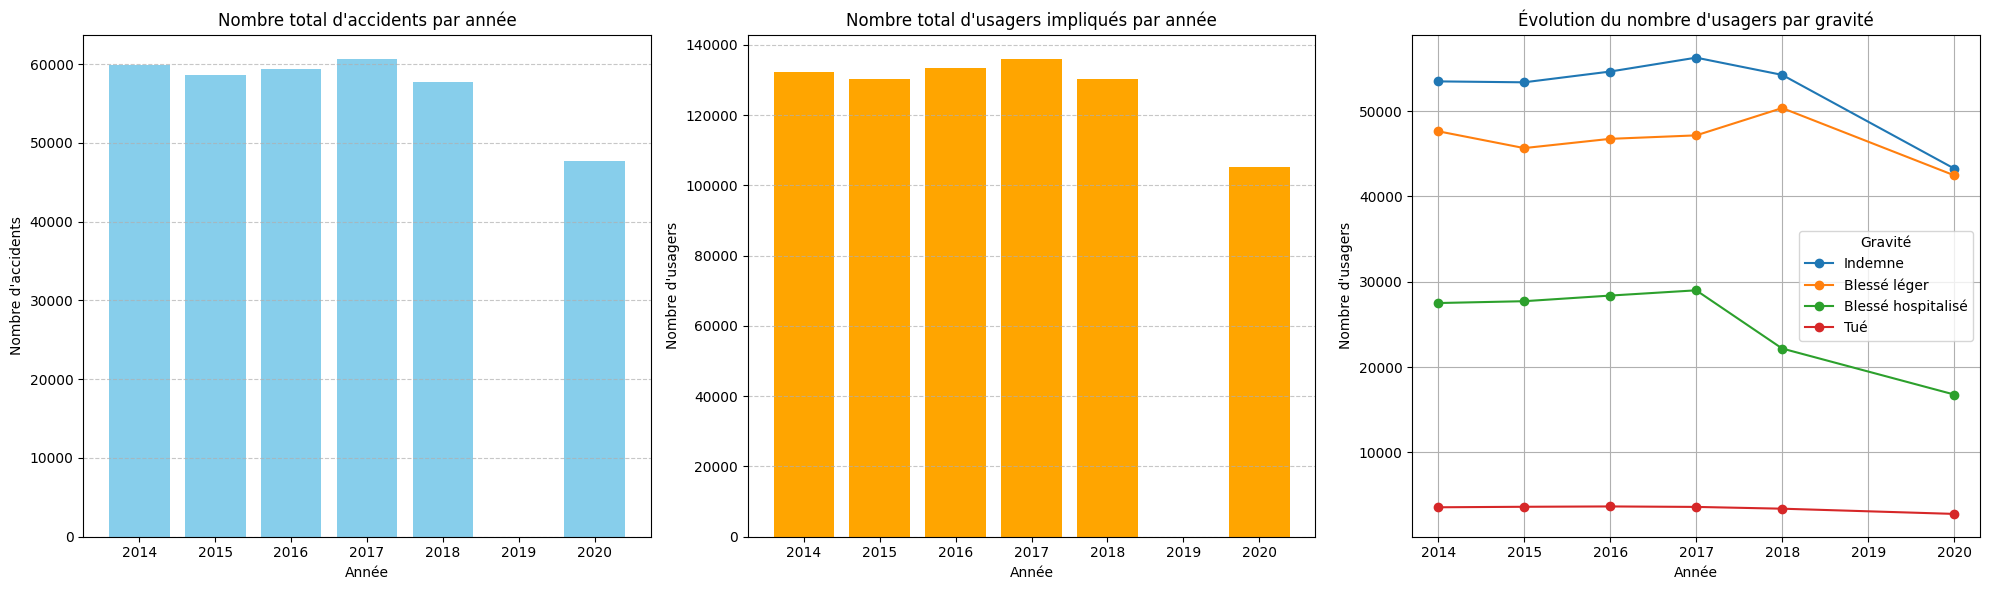

Moyenne 2014-2018 : 59285 accidents, 132435 usagers
2020 : 47744 accidents, 105295 usagers


In [9]:
# Paramètres
annees = [2014, 2015, 2016, 2017, 2018, 2020]
labels_grav = {
    1: "Indemne",
    2: "Tué",
    3: "Blessé hospitalisé",
    4: "Blessé léger"
}
ordre_grav = ["Indemne", "Blessé léger", "Blessé hospitalisé", "Tué"]

# Stocker les résultats
accidents_par_annee = []
usagers_par_annee = []
grav_par_annee = []

for annee in annees:
    # Lecture du CSV
    df_usagers = pd.read_csv(f'usagers_{annee}.csv', encoding='latin1', sep=';', on_bad_lines='skip')
    df_carac = pd.read_csv(f'caracteristiques_{annee}.csv', encoding='latin1', sep=';', on_bad_lines='skip')

    # Nettoyage basique
    df_usagers['grav'] = pd.to_numeric(df_usagers['grav'], errors='coerce')
    df_usagers = df_usagers[df_usagers['grav'] != -1]

    # Nombre d'accidents
    accidents_par_annee.append(df_usagers['Num_Acc'].nunique())

    # Nombre d'usagers (une ligne = un usager)
    usagers_par_annee.append(len(df_usagers))

    # Évolution gravité
    grav_counts = df_usagers['grav'].map(labels_grav).value_counts()
    grav_counts = grav_counts.reindex(ordre_grav, fill_value=0)
    grav_par_annee.append(grav_counts)

# Convertir en DataFrame
df_accidents = pd.DataFrame({'Année': annees, 'Accidents': accidents_par_annee})
df_usagers_total = pd.DataFrame({'Année': annees, 'Usagers': usagers_par_annee})
df_grav = pd.DataFrame(grav_par_annee, index=annees)

# Graphiques côte à côte
fig, axes = plt.subplots(1, 3, figsize=(20,6))

# Accidents
axes[0].bar(df_accidents['Année'], df_accidents['Accidents'], color='skyblue')
axes[0].set_title("Nombre total d'accidents par année")
axes[0].set_xlabel("Année")
axes[0].set_ylabel("Nombre d'accidents")
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Usagers
axes[1].bar(df_usagers_total['Année'], df_usagers_total['Usagers'], color='orange')
axes[1].set_title("Nombre total d'usagers impliqués par année")
axes[1].set_xlabel("Année")
axes[1].set_ylabel("Nombre d'usagers")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Gravité
for label in ordre_grav:
    axes[2].plot(df_grav.index, df_grav[label], marker='o', label=label)
axes[2].set_title("Évolution du nombre d'usagers par gravité")
axes[2].set_xlabel("Année")
axes[2].set_ylabel("Nombre d'usagers")
axes[2].legend(title="Gravité")
axes[2].grid(True)

plt.tight_layout()
plt.show()

# Moyenne des 5 premières années
acc_moy = df_accidents[df_accidents['Année'] != 2020]['Accidents'].mean()
usagers_moy = df_usagers_total[df_usagers_total['Année'] != 2020]['Usagers'].mean()
acc_2020 = df_accidents[df_accidents['Année'] == 2020]['Accidents'].values[0]
usagers_2020 = df_usagers_total[df_usagers_total['Année'] == 2020]['Usagers'].values[0]

print(f"Moyenne 2014-2018 : {acc_moy:.0f} accidents, {usagers_moy:.0f} usagers")
print(f"2020 : {acc_2020} accidents, {usagers_2020} usagers")

### Observations :
- Entre 2014 et 2018, le nombre d’accidents et d’usagers impliqués est relativement stable. En 2020, on observe une forte baisse, probablement liée au confinement et à la diminution de la circulation
- Le nombre de tués est faible et stable chaque année.
- Les autres catégories (blessés hospitalisés, légers, indemnes) diminuent en 2020.
- Fait intéressant : en 2020, les indemnes et blessés légers sont presque égaux, alors que les indemnes étaient majoritaires les années précédentes.

## 1.3. Répartition des accidents


Index(['Num_Acc', 'place', 'catu', 'grav', 'sexe', 'trajet', 'secu', 'locp',
       'actp', 'etatp', 'an_nais', 'num_veh', 'annee', 'id_vehicule', 'secu1',
       'secu2', 'secu3'],
      dtype='object')


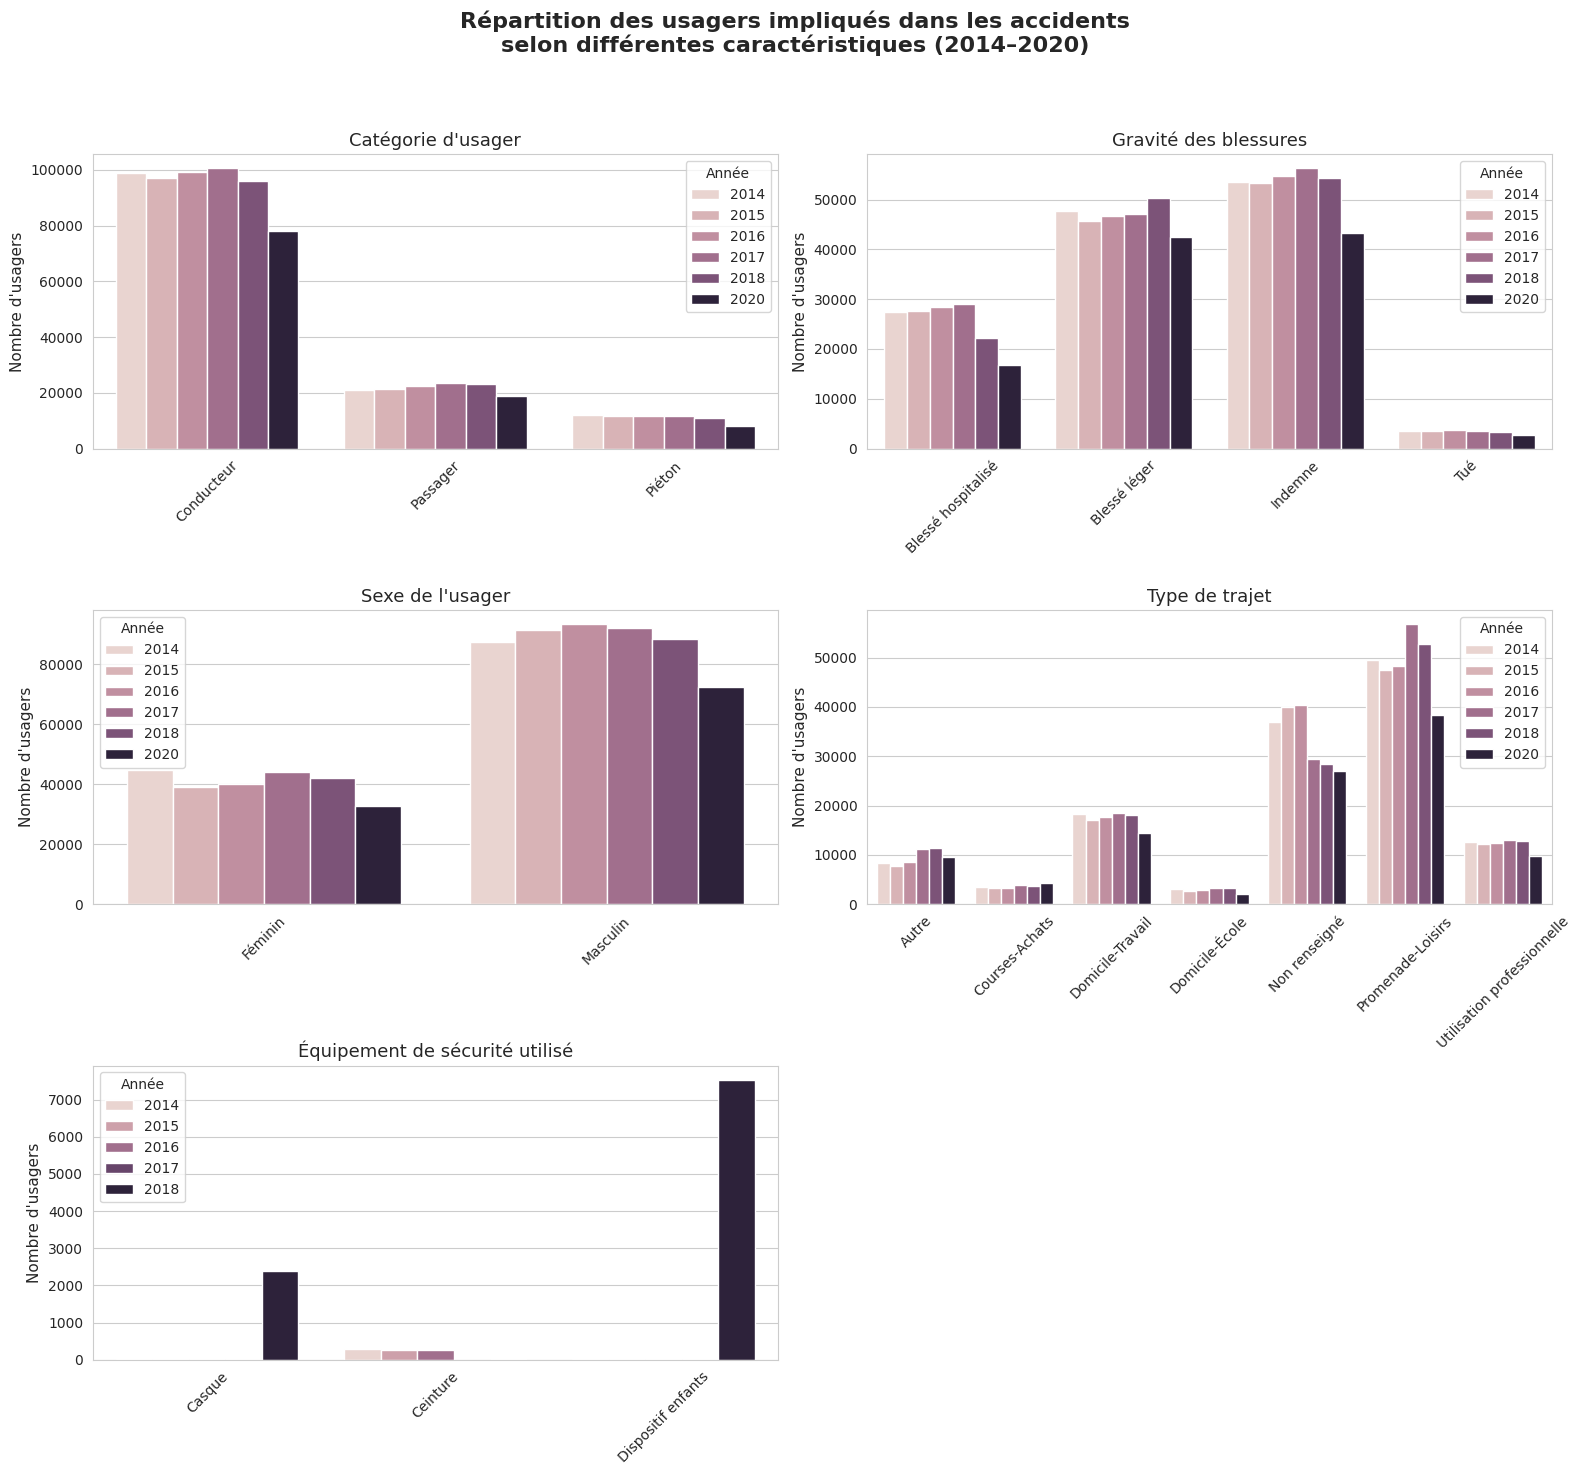

In [10]:
annees = [2014, 2015, 2016, 2017, 2018, 2020]
dfs = []

for annee in annees:
    filename = f"usagers_{annee}.csv"
    # Détecter automatiquement le séparateur
    with open(filename, "r") as f:
        dialect = csv.Sniffer().sniff(f.read(1024))
        sep = dialect.delimiter
    df_temp = pd.read_csv(filename, sep=sep)
    df_temp["annee"] = annee
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)

dfs = []

for annee in annees:
    df_temp = pd.read_csv(f"usagers_{annee}.csv", sep=";")
    df_temp["annee"] = annee
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)
print(df.columns)

# -----------------------------
# Dictionnaires de labels
# -----------------------------

catu_labels = {1: "Conducteur", 2: "Passager", 3: "Piéton"}

grav_labels = {
    1: "Indemne",
    2: "Tué",
    3: "Blessé hospitalisé",
    4: "Blessé léger"
}

sexe_labels = {1: "Masculin", 2: "Féminin"}

trajet_labels = {
    -1: "Non renseigné",
    0: "Non renseigné",
    1: "Domicile-Travail",
    2: "Domicile-École",
    3: "Courses-Achats",
    4: "Utilisation professionnelle",
    5: "Promenade-Loisirs",
    9: "Autre"
}

secu_labels = {
    -1: "Non renseigné",
    0: "Aucun équipement",
    1: "Ceinture",
    2: "Casque",
    3: "Dispositif enfants",
    4: "Gilet réfléchissant",
    5: "Airbag",
    6: "Gants",
    7: "Gants + Airbag",
    8: "Non déterminable",
    9: "Autre"
}

df["catu"] = df["catu"].map(catu_labels)
df["grav"] = df["grav"].map(grav_labels)
df["sexe"] = df["sexe"].map(sexe_labels)
df["trajet"] = df["trajet"].map(trajet_labels)

if "secu" in df.columns:
    df["secu"] = df["secu"].map(secu_labels)

# -----------------------------
# Noms propres pour les graphiques
# -----------------------------

variables = ["catu", "grav", "sexe", "trajet"]
if "secu" in df.columns:
    variables.append("secu")

titles = {
    "catu": "Catégorie d'usager",
    "grav": "Gravité des blessures",
    "sexe": "Sexe de l'usager",
    "trajet": "Type de trajet",
    "secu": "Équipement de sécurité utilisé"
}

# -----------------------------
# Style global
# -----------------------------

sns.set_style("whitegrid")
plt.rcParams.update({"font.size": 10})

n = len(variables)
fig, axes = plt.subplots(nrows=(n+1)//2, ncols=2, figsize=(16, 5*((n+1)//2)))
axes = axes.flatten()

for i, var in enumerate(variables):

    counts = df.groupby(["annee", var]).size().reset_index(name="nombre")

    sns.barplot(
        data=counts,
        x=var,
        y="nombre",
        hue="annee",
        ax=axes[i]
    )

    axes[i].set_title(titles[var], fontsize=13)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Nombre d'usagers", fontsize=11)

    axes[i].tick_params(axis="x", rotation=45)
    axes[i].legend(title="Année")

# Supprimer axes vides
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# -----------------------------
# Titre général
# -----------------------------

fig.suptitle(
    "Répartition des usagers impliqués dans les accidents\nselon différentes caractéristiques (2014–2020)",
    fontsize=16,
    weight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Observations
Les données révèlent plusieurs informations sur la répartition des accidents. Tout d’abord, les conducteurs sont les personnes les plus touchées par les accidents, ce qui peut s’expliquer par le fait qu’une grande partie des trajets dans notre société est effectuée individuellement.

On observe également une majorité d’hommes impliqués dans ces accidents, leur nombre étant presque le double de celui des femmes.

Les trajets les plus fréquents lors des accidents concernent les promenades et les loisirs. Cela pourrait s’expliquer par une plus grande exposition ou des comportements plus risqués lors de ces déplacements.

Le graphique sur la sécurité n’est pas complet et manque d’informations. Nous allons donc créer d’autres graphiques pour mieux analyser cette variable, car elle pourrait être très utile pour étudier la gravité des accidents.

En ce qui concerne la gravité, la majorité des accidents n’est pas mortelle : les victimes ressortent indemnes ou légèrement blessées.

## 1.4. Répartition spatiale des accidents en France

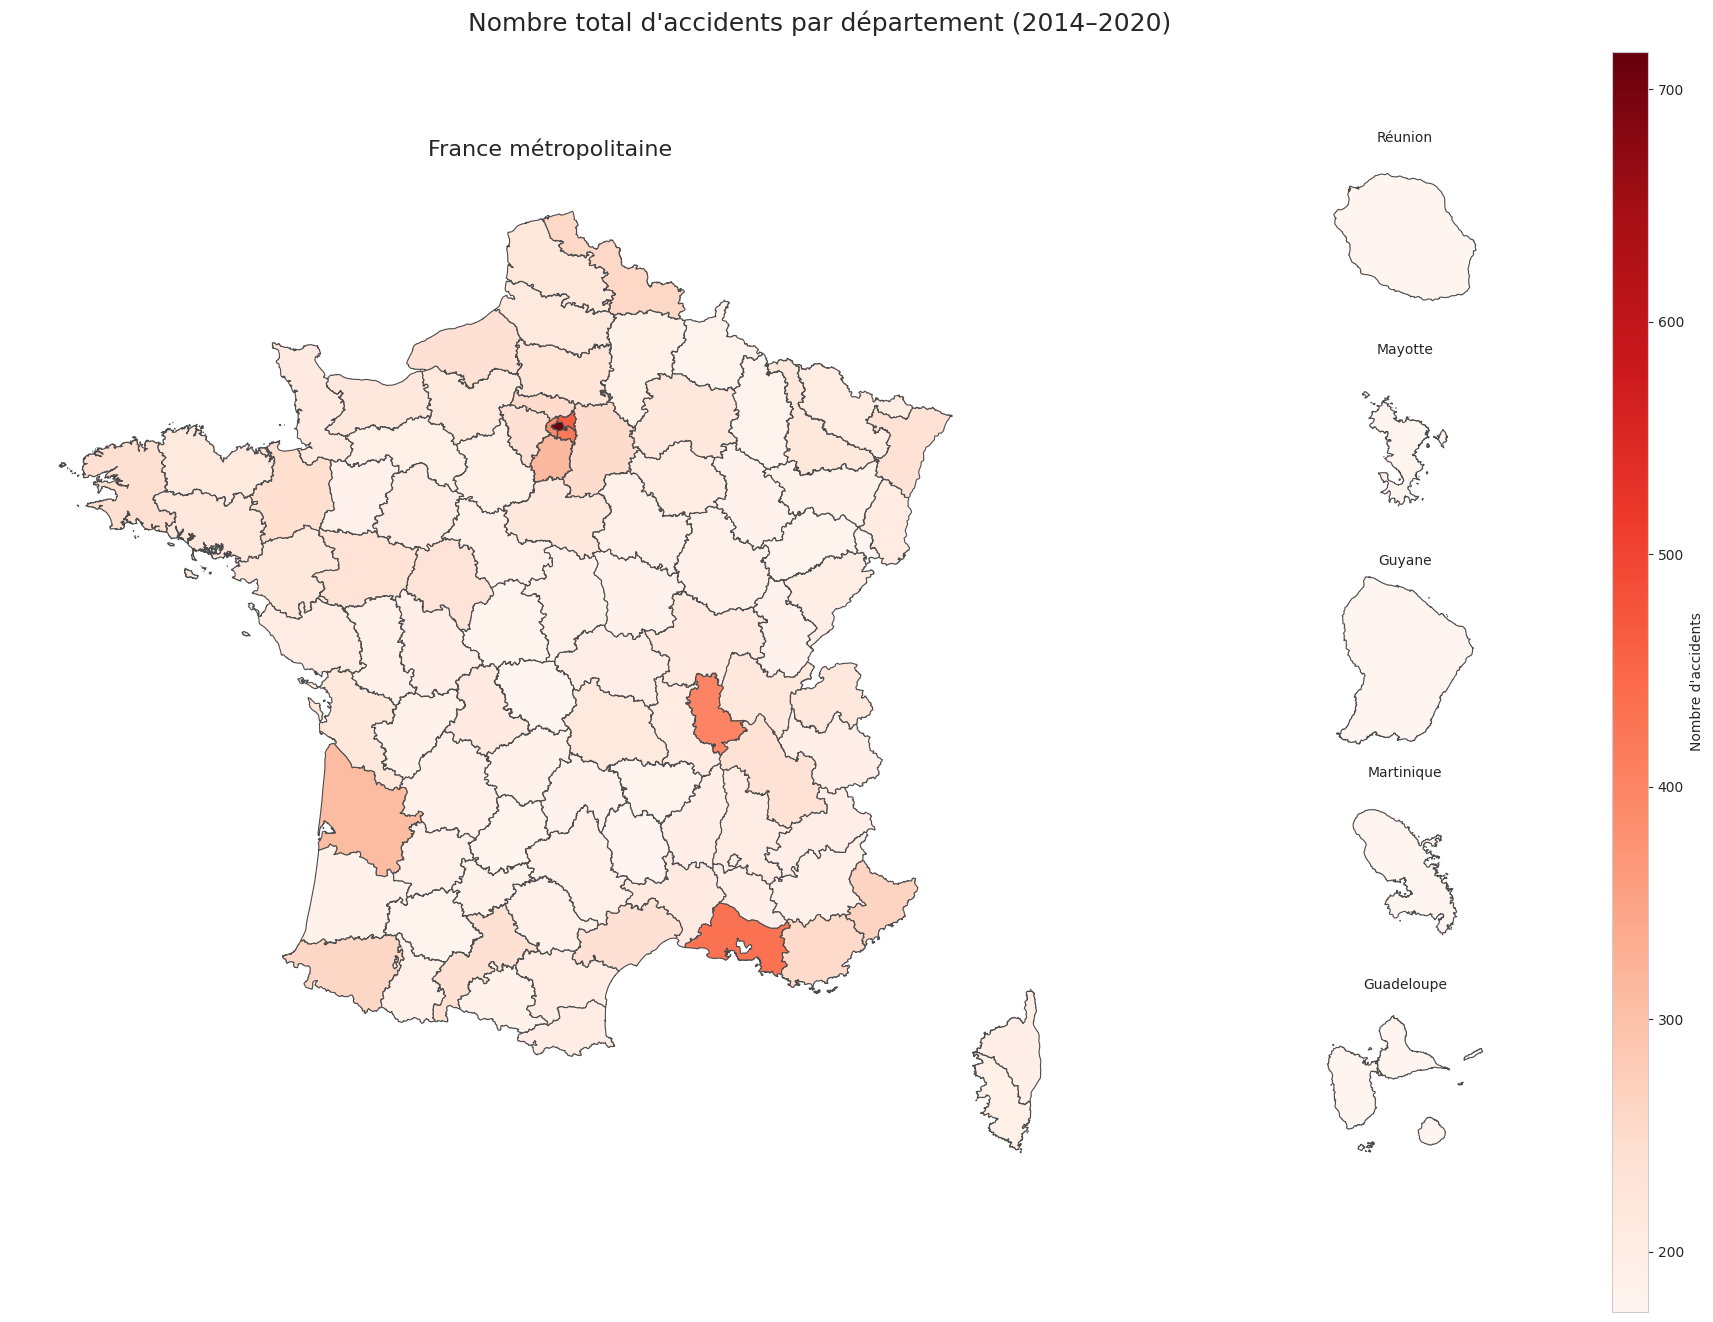

In [11]:
# --- Charger tous les accidents par département (toutes années) ---
annees = [2014, 2015, 2016, 2017, 2018, 2020]
dfs = []
for annee in annees:
    df = pd.read_csv(f'caracteristiques_{annee}.csv', encoding='latin1', sep=';', on_bad_lines='skip')
    df = df[df['dep'] != -1][['dep', 'Num_Acc']].drop_duplicates()
    dfs.append(df)

df_all = pd.concat(dfs)
df_dep = df_all.groupby('dep')['Num_Acc'].count().reset_index()
df_dep.rename(columns={'Num_Acc': 'nb_accidents'}, inplace=True)

# --- Normaliser les codes département ---
df_dep['dep'] = df_dep['dep'].astype(str)
df_dep['dep'] = df_dep['dep'].replace({"2A":"20A", "2B":"20B"})
df_dep['dep'] = df_dep['dep'].str.replace(" ", "")

# --- Télécharger GeoJSON avec outre-mer ---
url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements-avec-outre-mer.geojson"
r = requests.get(url)
with open("departements-outre-mer.geojson", "wb") as f:
    f.write(r.content)

departements = gpd.read_file("departements-outre-mer.geojson")
departements['code'] = departements['code'].astype(str)
departements['code'] = departements['code'].replace({"2A":"20A", "2B":"20B"})
departements['code'] = departements['code'].str.replace(" ", "")

# --- Noms DOM-TOM ---
dom_names = {
    "971": "Guadeloupe",
    "972": "Martinique",
    "973": "Guyane",
    "974": "Réunion",
    "976": "Mayotte",
    "975": "Saint-Pierre-et-Miquelon",
    "977": "Saint-Barthélemy",
    "978": "Saint-Martin",
    "984": "Terres australes",
    "986": "Wallis-et-Futuna",
    "987": "Polynésie",
    "988": "Nouvelle-Calédonie"
}

# --- Séparer métropole et DOM-TOM ---
metropole = departements[departements['code'].astype(str).str.match(r'^(0?[1-9]|[1-8][0-9]|9[0-5]|20A|20B)$')]
domtom = departements[~departements.index.isin(metropole.index)]

map_meta = metropole.merge(df_dep, left_on="code", right_on="dep", how="left").fillna(0)
map_dom = domtom.merge(df_dep, left_on="code", right_on="dep", how="left").fillna(0)

# Ajouter colonne avec noms DOM-TOM
map_dom['nom_dom'] = map_dom['code'].map(dom_names).fillna(map_dom['code'])

# --- Créer figure avec axes pour métropole + DOM-TOM ---
fig = plt.figure(figsize=(18, 14))

# Métropole principale
ax_meta = fig.add_axes([0.05, 0.05, 0.6, 0.9])
map_meta.plot(column="nb_accidents", cmap="Reds", linewidth=0.8, edgecolor='0.3', legend=False, ax=ax_meta)
ax_meta.set_title("France métropolitaine", fontsize=16)
ax_meta.axis('off')

# DOM-TOM : axes alignés verticalement, plus petits et espacés
dom_codes = list(map_dom['code'])
n_dom = len(dom_codes)
total_height = 0.9  # hauteur totale disponible
height = total_height / n_dom * 0.7  # réduire taille de chaque DOM pour plus d'espacement
y_start = 0.15  # position de départ légèrement plus haute pour le premier DOM

for i, code in enumerate(dom_codes):
    ax_dom = fig.add_axes([0.7, y_start + i*(height*1.2), 0.25, height])  # x, y, width, height
    single_dom = map_dom[map_dom['code'] == code]

    minx, miny, maxx, maxy = single_dom.total_bounds
    single_dom.plot(column="nb_accidents", cmap="Reds", linewidth=0.8, edgecolor='0.3', ax=ax_dom)
    ax_dom.set_xlim(minx-0.1, maxx+0.1)
    ax_dom.set_ylim(miny-0.1, maxy+0.1)

    # Titre directement au-dessus de chaque DOM
    ax_dom.set_title(single_dom['nom_dom'].values[0], fontsize=10, pad=5)
    ax_dom.axis('off')

# Ajouter légende globale sur la droite
sm = plt.cm.ScalarMappable(cmap="Reds", norm=plt.Normalize(vmin=map_dom['nb_accidents'].min(), vmax=map_dom['nb_accidents'].max()))
sm._A = []
cbar_ax = fig.add_axes([0.94, 0.05, 0.02, 0.9])  # x, y, width, height
fig.colorbar(sm, cax=cbar_ax, label="Nombre d'accidents")

plt.suptitle("Nombre total d'accidents par département (2014–2020)", fontsize=18)
plt.show()

### Observations

On observe une forte concentration d’accidents dans les départements les plus urbanisés. Le département de Paris apparaît comme le plus foncé sur la carte. Les départements de la petite couronne présentent également un nombre élevé d’accidents. En dehors de l’Île-de-France, les Bouches-du-Rhône et le Rhône se distinguent également.

Cette répartition semble liée à la densité de population et au volume de circulation. Les zones fortement urbanisées concentrent davantage d’habitants, de déplacements quotidiens et d’infrastructures routières, ce qui augmente mécaniquement le nombre total d’accidents.

# 2. Analyse des caractéristiques des accidents




## 2.1. Gravité des accidents selon la luminosité

Ici, nous souhaitons analyser comment la gravité des accidents varie selon les conditions de luminosité.  
L’objectif est de voir si certaines conditions (plein jour, crépuscule, éclairages…) sont associées à un risque plus élevé de blessés grave ou de tués.

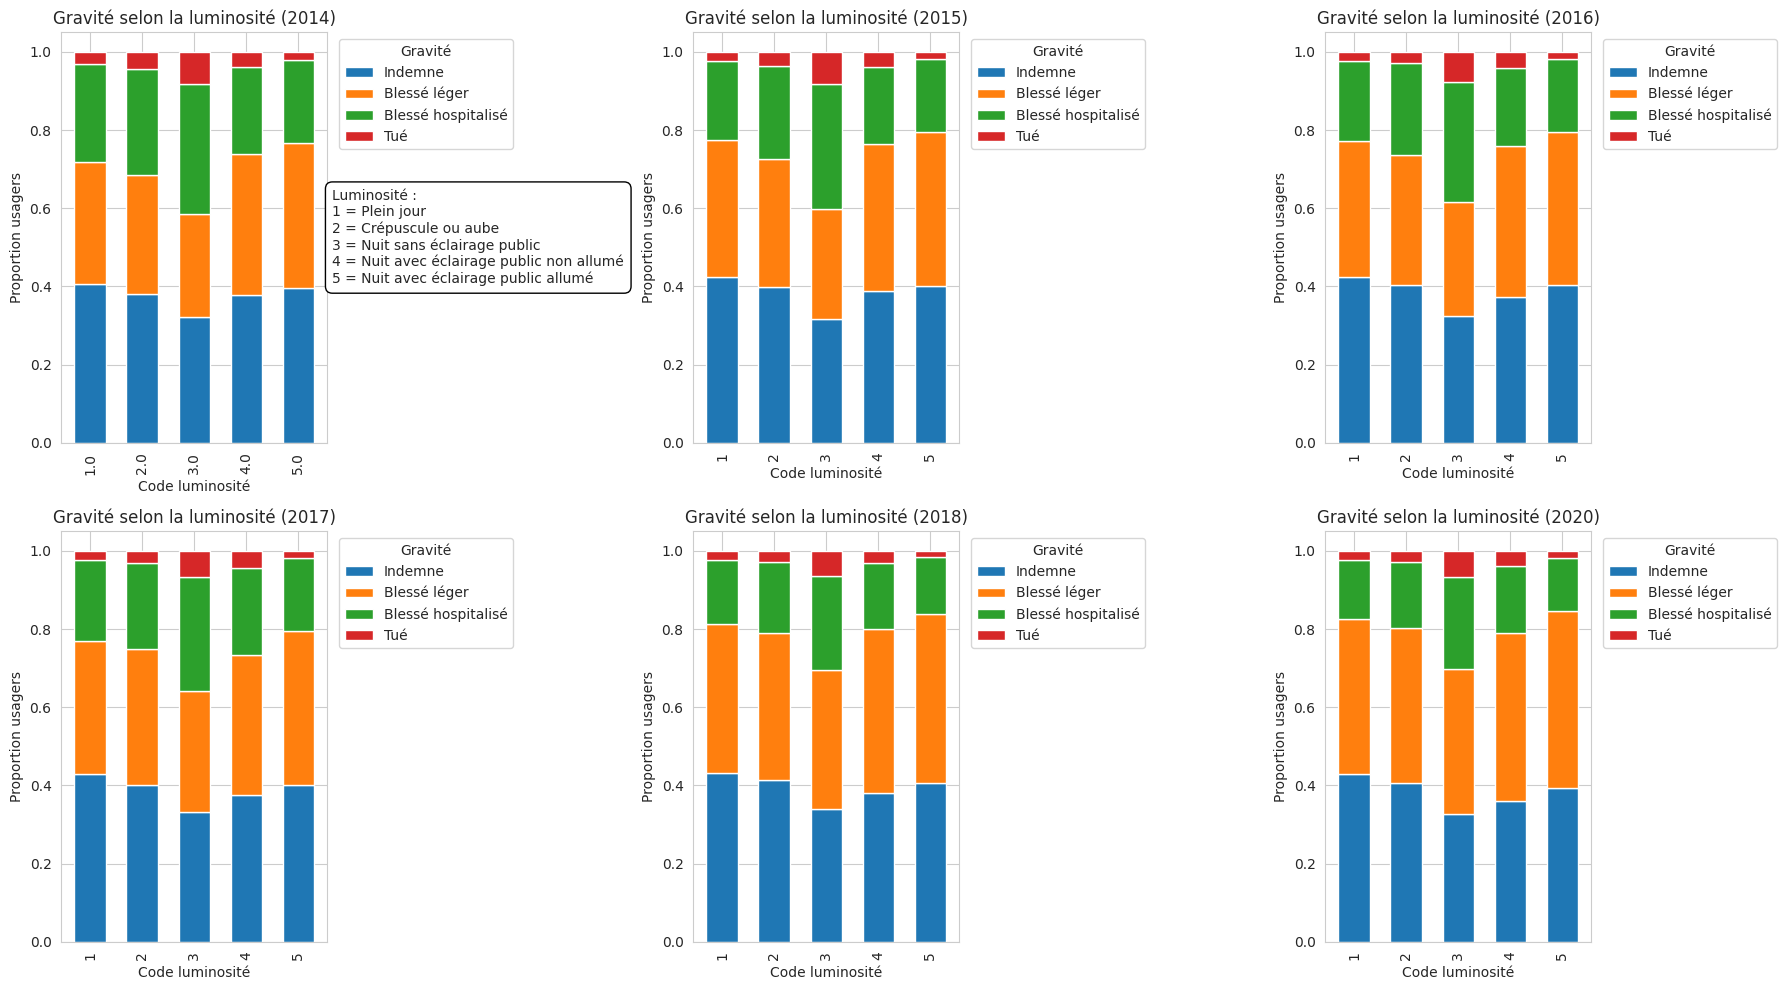

In [12]:
# --- Paramètres ---
annees = [2014, 2015, 2016, 2017, 2018, 2020]  # 2019 exclu
ordre_grav = ["Indemne", "Blessé léger", "Blessé hospitalisé", "Tué"]
labels_grav = {
    1: "Indemne",
    2: "Tué",
3: "Blessé hospitalisé",
4: "Blessé léger"
}

# --- Préparer la figure avec subplots ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))  # 2 lignes x 3 colonnes
axes = axes.flatten()  # pour itérer facilement

for i, annee in enumerate(annees):
    # --- Charger CSV ---
    # Ajout de l'encodage 'latin1' et du séparateur ';' pour corriger les erreurs
    # Ajout de on_bad_lines='skip' pour ignorer les lignes mal formées
    df_carac = pd.read_csv(f"caracteristiques_{annee}.csv", encoding='latin1', sep=';', on_bad_lines='skip')
    df_usagers = pd.read_csv(f"usagers_{annee}.csv", encoding='latin1', sep=';', on_bad_lines='skip')

    # Forcer lum et Num_Acc en string dans les deux tables
    df_carac['Num_Acc'] = df_carac['Num_Acc'].astype(str)
    df_usagers['Num_Acc'] = df_usagers['Num_Acc'].astype(str)
    df_carac['lum'] = df_carac['lum'].astype(str)
    df_carac = df_carac[df_carac["lum"] != "-1"] # Suppression de la valeur -1 car peu de données concernées

    # Jointure
    df = pd.merge(df_carac[['Num_Acc', 'lum']], df_usagers[['Num_Acc', 'grav']], on='Num_Acc')

    # Mapping gravité
    df['grav_label'] = df['grav'].map(labels_grav)

    # Table croisée
    table = pd.crosstab(df['lum'], df['grav_label'], normalize='index')
    table = table[ordre_grav]

    # Graphique
    ax = axes[i]
    table.plot(kind='bar', stacked=True, ax=ax, width=0.6)
    ax.set_title(f"Gravité selon la luminosité ({annee})")
    ax.set_xlabel("Code luminosité")
    ax.set_ylabel("Proportion usagers")
    ax.legend(title="Gravité", bbox_to_anchor=(1.02, 1), loc="upper left")

    # Labels luminosité
    if i == 0:
        lum_labels_text = (
            "Luminosité :\n"
            "1 = Plein jour\n"
            "2 = Crépuscule ou aube\n"
            "3 = Nuit sans éclairage public\n"
            "4 = Nuit avec éclairage public non allumé\n"
            "5 = Nuit avec éclairage public allumé"
        )
        ax.text(1.02, 0.5, lum_labels_text, transform=ax.transAxes,
                fontsize=10, va='center', ha='left',
                bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))

# Ajuster l'espace pour que ça ne se chevauche pas
plt.tight_layout()
plt.show()

### Observations

- Les tendances sont relativement stables d'une année sur l'autre.
- On observe que les accidents survenant la nuit sans éclairage public présentent une proportion plus élevée de blessés hospitalisés et de tués, ce qui indique que ces conditions sont particulièrement à risque.

## 2.2. Gravité des accidents selon l'atmosphère

Dans cette partie, nous analysons la manière dont la gravité des accidents varie en fonction des conditions météorologiques.
Il est également pertinent d’examiner la fréquence des différentes conditions (vent, neige/grêle, pluie, etc.), car certaines situations climatiques sont plus rares que d’autres en France et peuvent influencer l’interprétation des résultats.

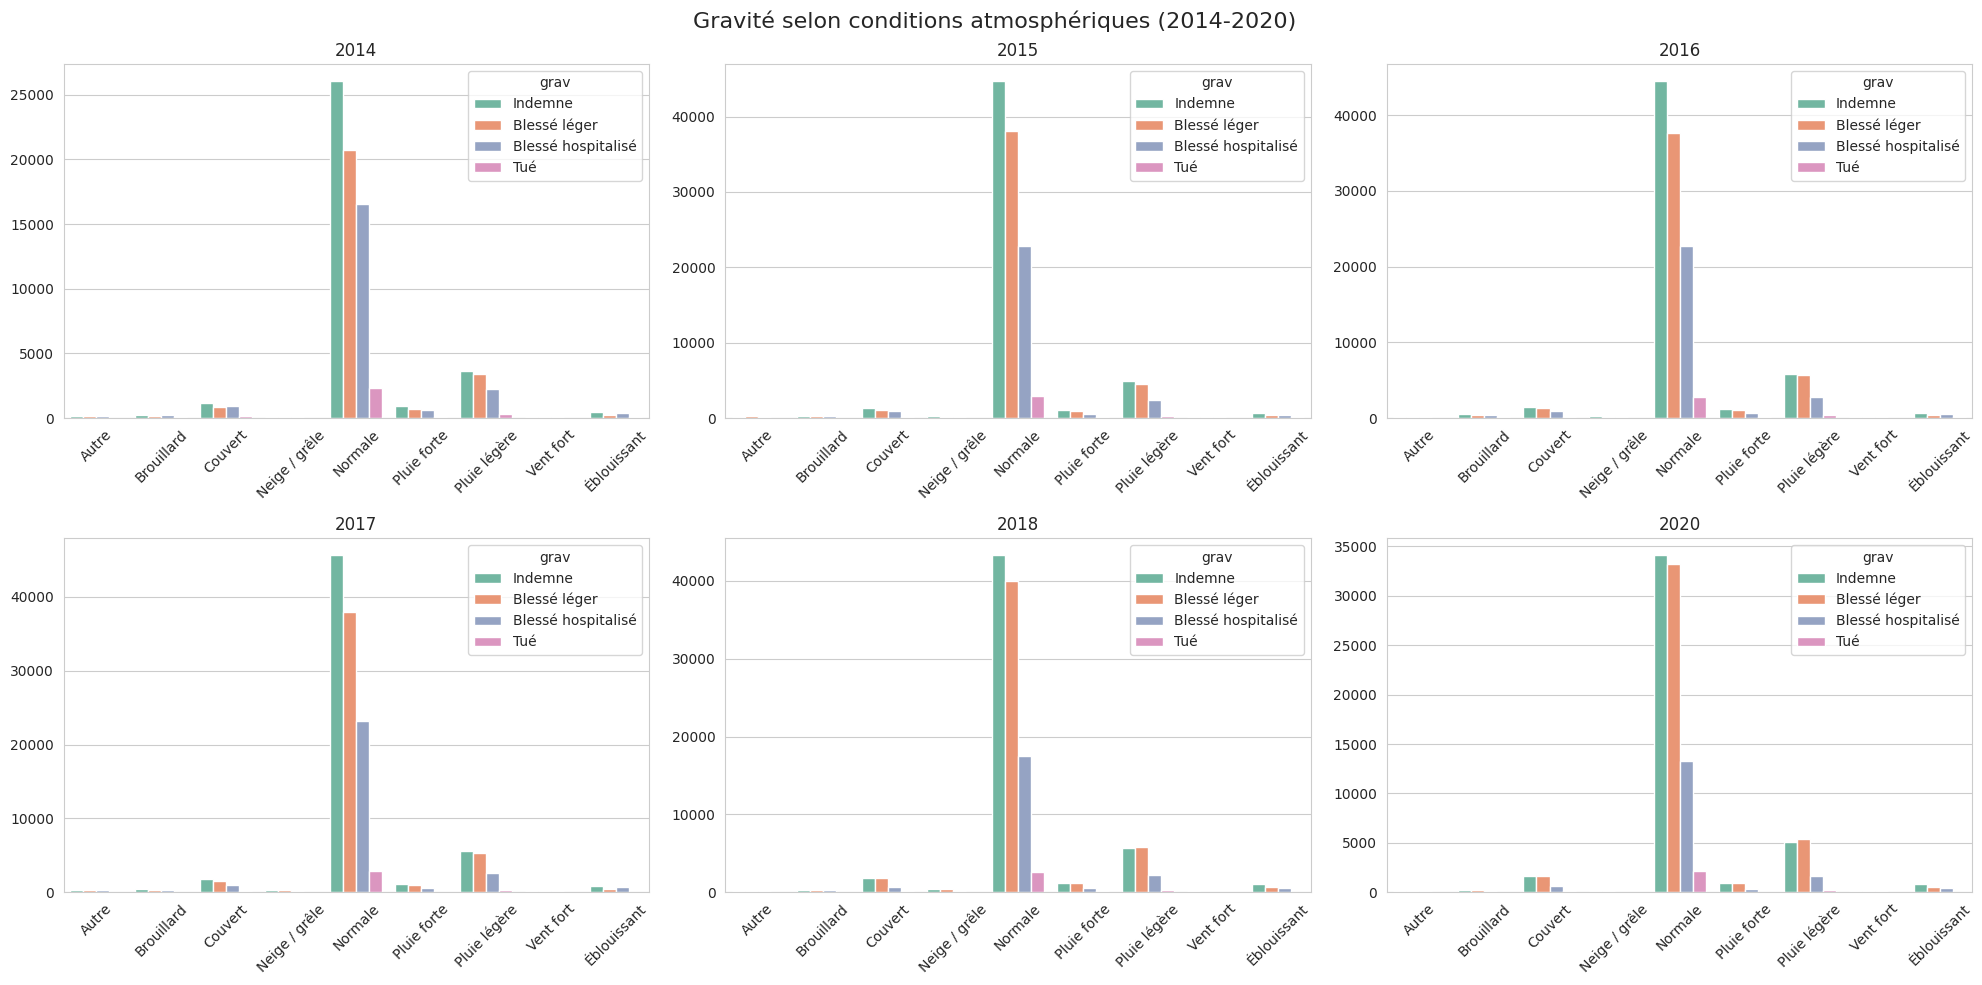

In [13]:
annees = [2014, 2015, 2016, 2017, 2018, 2020]

labels_atm = {
    1: "Normale",
    2: "Pluie légère",
    3: "Pluie forte",
    4: "Neige / grêle",
    5: "Brouillard",
    6: "Vent fort",
    7: "Éblouissant",
    8: "Couvert",
    9: "Autre"
}

labels_grav = {
    1: "Indemne",
    4: "Blessé léger",
    3: "Blessé hospitalisé",
    2: "Tué"
}

ordre_grav = ["Indemne", "Blessé léger", "Blessé hospitalisé", "Tué"]

# Changement palette
palette_vive = sns.color_palette("Set2", 4)

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, annee in enumerate(annees):

    df_usagers = pd.read_csv(f'usagers_{annee}.csv', encoding='latin1', sep=';', on_bad_lines='skip')
    df_carac = pd.read_csv(f'caracteristiques_{annee}.csv', encoding='latin1', sep=';', on_bad_lines='skip')

    # Forcer Num_Acc en string dans les deux tables
    df_carac['Num_Acc'] = df_carac['Num_Acc'].astype(str)
    df_usagers['Num_Acc'] = df_usagers['Num_Acc'].astype(str)

    df = pd.merge(df_carac[['Num_Acc', 'atm']],
                  df_usagers[['Num_Acc', 'grav']],
                  on='Num_Acc',
                  how='inner')

    df['atm'] = pd.to_numeric(df['atm'], errors='coerce')
    df['grav'] = pd.to_numeric(df['grav'], errors='coerce')

    df = df[(df['atm'] != -1) & (df['grav'] != -1)]

    # Remplacer codes par labels
    df['atm'] = df['atm'].map(labels_atm)
    df['grav'] = df['grav'].map(labels_grav)

    counts = df.groupby(['atm', 'grav']).size().reset_index(name='nombre')

    sns.barplot(
        data=counts,
        x='atm',
        y='nombre',
        hue='grav',
        hue_order=ordre_grav,
        palette=palette_vive,
        ax=axes[i]
    )

    axes[i].set_title(f"{annee}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].tick_params(axis='x', rotation=45)

fig.suptitle("Gravité selon conditions atmosphériques (2014-2020)", fontsize=16)
plt.tight_layout()
plt.show()

<Figure size 1100x600 with 0 Axes>

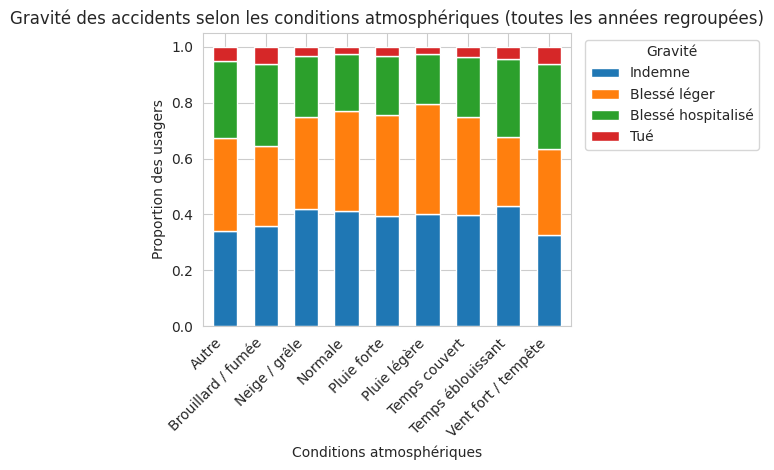

In [14]:
annees = [2014, 2015, 2016, 2017, 2018, 2020]

dfs = []

for annee in annees:
    df_usagers = pd.read_csv(f'usagers_{annee}.csv', encoding='latin1', sep=';', on_bad_lines='skip')
    df_carac = pd.read_csv(f'caracteristiques_{annee}.csv', encoding='latin1', sep=';', on_bad_lines='skip')

    # Forcer Num_Acc en string dans les deux tables
    df_carac['Num_Acc'] = df_carac['Num_Acc'].astype(str)
    df_usagers['Num_Acc'] = df_usagers['Num_Acc'].astype(str)

    df_merge = pd.merge(
        df_carac[['Num_Acc', 'atm']],
        df_usagers[['Num_Acc', 'grav']],
        on='Num_Acc',
        how='inner'
    )

    dfs.append(df_merge)

# Regrouper toutes les années
df = pd.concat(dfs, ignore_index=True)

# Nettoyage
df["atm"] = pd.to_numeric(df["atm"], errors="coerce")
df["grav"] = pd.to_numeric(df["grav"], errors="coerce")
df = df[(df["atm"] != -1) & (df["grav"] != -1)]

# Labels gravité
labels_grav = {
    1: "Indemne",
    4: "Blessé léger",
    3: "Blessé hospitalisé",
    2: "Tué"
}

ordre_grav = ["Indemne", "Blessé léger", "Blessé hospitalisé", "Tué"]

df["grav_label"] = df["grav"].map(labels_grav)

# Labels météo
labels_atm = {
    1: "Normale",
    2: "Pluie légère",
    3: "Pluie forte",
    4: "Neige / grêle",
    5: "Brouillard / fumée",
    6: "Vent fort / tempête",
    7: "Temps éblouissant",
    8: "Temps couvert",
    9: "Autre"
}

df["atm_label"] = df["atm"].map(labels_atm)

# Tableau proportions par météo
table = pd.crosstab(df["atm_label"], df["grav_label"], normalize="index")
table = table[ordre_grav]

# Graphique empilé
plt.figure(figsize=(11,6))
table.plot(kind="bar", stacked=True, width=0.6)

plt.ylabel("Proportion des usagers")
plt.xlabel("Conditions atmosphériques")
plt.title("Gravité des accidents selon les conditions atmosphériques (toutes les années regroupées)")

plt.xticks(rotation=45, ha="right")
plt.legend(title="Gravité", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

### Observations

- La grande majorité des accidents surviennent en conditions dites “normales”, ce qui crée une répartition très inégale des effectifs.
- Les conditions de vent fort ou de brouillard semblent associées à une proportion légèrement plus élevée de décès. Néanmoins, ces situations météorologiques sont rares dans le jeu de données, ce qui limite la robustesse statistique de cette observation.

### **Pour les prochains graphiques, si les tendances s'avèrent être stables pour chaque année, un seul graphique regroupant toutes les années sera fourni pour plus de lisibilité.**

## 2.3. Gravité des accidents selon le type de collision

Dans cette partie, nous analysons comment la gravité des accidents varie selon le type de collision, en mettant en parallèle la fréquence des différents types de collision.

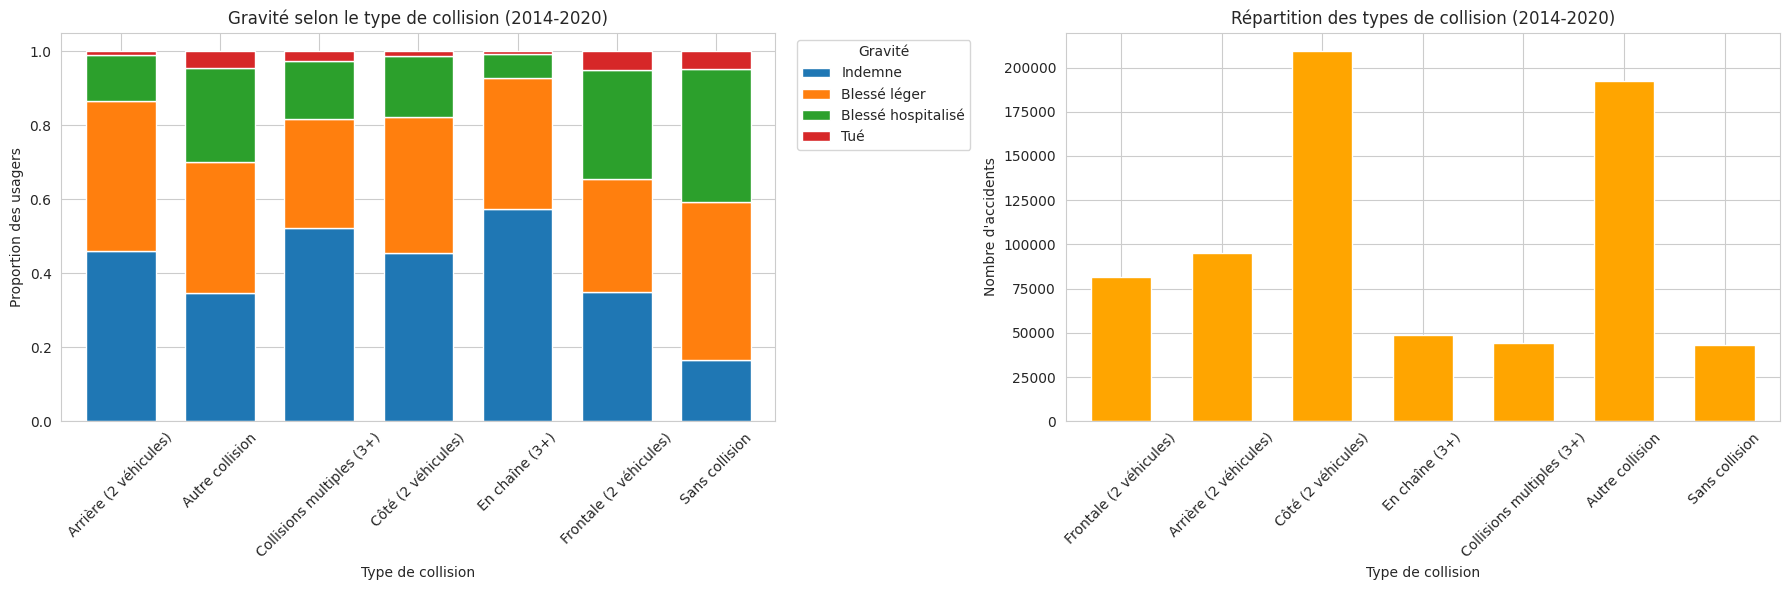

In [15]:
# Paramètres
annees = [2014, 2015, 2016, 2017, 2018, 2020]

labels_grav = {
    1: "Indemne",
    4: "Blessé léger",
    3: "Blessé hospitalisé",
    2: "Tué"
}
ordre_grav = ["Indemne", "Blessé léger", "Blessé hospitalisé", "Tué"]

labels_col = {
    1: "Frontale (2 véhicules)",
    2: "Arrière (2 véhicules)",
    3: "Côté (2 véhicules)",
    4: "En chaîne (3+)",
    5: "Collisions multiples (3+)",
    6: "Autre collision",
    7: "Sans collision"
}

# Regrouper toutes les années
dfs = []
for annee in annees:
    df_usagers = pd.read_csv(f'usagers_{annee}.csv', encoding='latin1', sep=';', on_bad_lines='skip')
    df_carac = pd.read_csv(f'caracteristiques_{annee}.csv', encoding='latin1', sep=';', on_bad_lines='skip')

    # Forcer Num_Acc en string
    df_carac['Num_Acc'] = df_carac['Num_Acc'].astype(str)
    df_usagers['Num_Acc'] = df_usagers['Num_Acc'].astype(str)

    df = pd.merge(
        df_carac[['Num_Acc', 'col']],
        df_usagers[['Num_Acc', 'grav']],
        on='Num_Acc',
        how='inner'
    )

    df["col"] = pd.to_numeric(df["col"], errors="coerce")
    df["grav"] = pd.to_numeric(df["grav"], errors="coerce")

    df = df[(df["col"] != -1) & (df["grav"] != -1)]
    dfs.append(df)

# Fusionner toutes les années
df_all = pd.concat(dfs, ignore_index=True)

# Ajouter les labels
df_all["grav_label"] = df_all["grav"].map(labels_grav)
df_all["col_label"] = df_all["col"].map(labels_col)

# Préparer les tableaux
# Proportions
table_prop = pd.crosstab(df_all["col_label"], df_all["grav_label"], normalize="index")
table_prop = table_prop[ordre_grav]

# Effectifs
table_count = df_all["col_label"].value_counts().reindex(labels_col.values(), fill_value=0)

# --- Graphiques côte à côte ---
fig, axes = plt.subplots(1, 2, figsize=(18,6))

# Proportions
table_prop.plot(kind="bar", stacked=True, width=0.7, ax=axes[0])
axes[0].set_ylabel("Proportion des usagers")
axes[0].set_xlabel("Type de collision")
axes[0].set_title("Gravité selon le type de collision (2014-2020)")
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title="Gravité", bbox_to_anchor=(1.02,1), loc="upper left")

# Effectifs
table_count.plot(kind="bar", width=0.6, color='orange', ax=axes[1])
axes[1].set_ylabel("Nombre d'accidents")
axes[1].set_xlabel("Type de collision")
axes[1].set_title("Répartition des types de collision (2014-2020)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Les proportions et effectifs étant similaires d’une année à l’autre, les données ont été regroupées afin d’obtenir une vision synthétique.

### Observations

- Effectifs :
Les accidents de type “*côté (2 véhicules)*” sont les plus fréquents, suivis des “*Autres collisions*”.

- Gravité :

  - Les accidents “*Sans collision*” se démarquent avec un nombre relativement plus élevé de tués et de blessés hospitalisés.

  - Viennent ensuite les collisions frontales, avec un impact grave significatif.

  - Enfin, la catégorie “Autre collision” apparaît en troisième position pour les accidents graves.

## 2.4. Gravité des accidents selon le département

Dans cette partie, nous analysons la proportion d’accidents graves (tués et blessés hospitalisés) par département.
Contrairement à la première carte (cf "*1.4. Répartition spatiale des accidents en France*") qui présentait le volume total d’accidents, cette représentation permet d’identifier les territoires où les accidents sont proportionnellement les plus sévères.

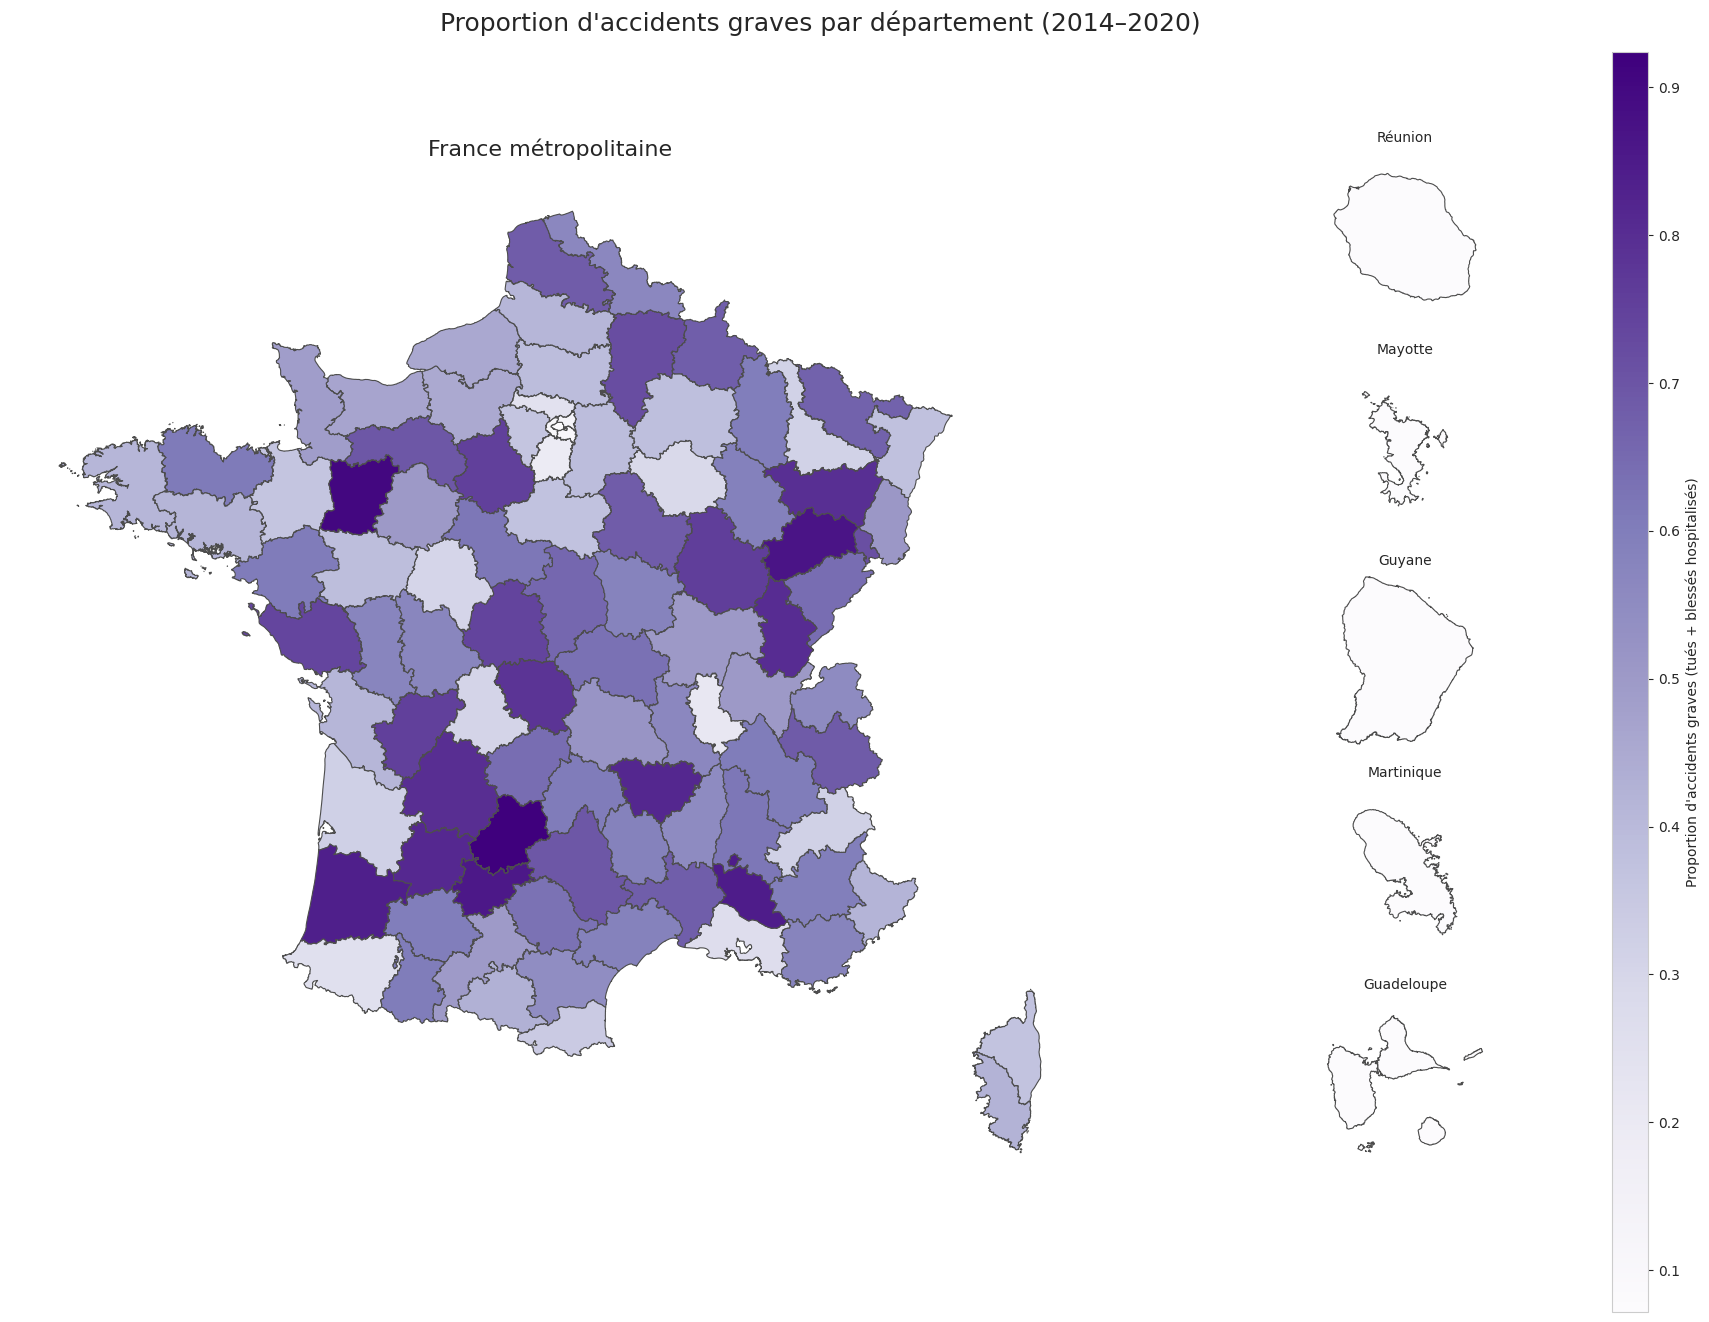

In [16]:
# --- Charger tous les accidents avec gravité ---
annees = [2014, 2015, 2016, 2017, 2018, 2020]
dfs = []

for annee in annees:
    df_carac = pd.read_csv(f'caracteristiques_{annee}.csv',
                           encoding='latin1',
                           sep=';',
                           on_bad_lines='skip')

    df_usagers = pd.read_csv(f'usagers_{annee}.csv',
                             encoding='latin1',
                             sep=';',
                             on_bad_lines='skip')

    # Assurer même type pour fusion
    df_carac['Num_Acc'] = df_carac['Num_Acc'].astype(str)
    df_usagers['Num_Acc'] = df_usagers['Num_Acc'].astype(str)

    # Fusion pour récupérer gravité
    df_merged = pd.merge(
        df_carac[['dep', 'Num_Acc']],
        df_usagers[['Num_Acc', 'grav']],
        on='Num_Acc',
        how='inner'
    )

    # Supprimer dep invalides
    df_filtered = df_merged[df_merged['dep'] != -1][['dep', 'Num_Acc', 'grav']]

    # Compter chaque accident une seule fois
    df_filtered = df_filtered.drop_duplicates()

    dfs.append(df_filtered)

df_all = pd.concat(dfs)

# --- Total accidents par département ---
total_dep = df_all.groupby('dep')['Num_Acc'].nunique().reset_index()
total_dep.rename(columns={'Num_Acc': 'nb_total'}, inplace=True)

# --- Accidents graves (tués + blessés hospitalisés = grav 2 ou 3) ---
grave_dep = df_all[df_all['grav'].isin([2, 3])] \
    .groupby('dep')['Num_Acc'].nunique().reset_index()

grave_dep.rename(columns={'Num_Acc': 'nb_graves'}, inplace=True)

# --- Fusion et proportion ---
df_dep = total_dep.merge(grave_dep, on='dep', how='left')
df_dep['nb_graves'] = df_dep['nb_graves'].fillna(0)

df_dep['prop_graves'] = df_dep['nb_graves'] / df_dep['nb_total']

# --- Normaliser codes département ---
df_dep['dep'] = df_dep['dep'].astype(str)
df_dep['dep'] = df_dep['dep'].replace({"2A": "20A", "2B": "20B"})
df_dep['dep'] = df_dep['dep'].str.replace(" ", "")

# --- Télécharger GeoJSON ---
url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements-avec-outre-mer.geojson"
r = requests.get(url)

with open("departements-outre-mer.geojson", "wb") as f:
    f.write(r.content)

departements = gpd.read_file("departements-outre-mer.geojson")

departements['code'] = departements['code'].astype(str)
departements['code'] = departements['code'].replace({"2A": "20A", "2B": "20B"})
departements['code'] = departements['code'].str.replace(" ", "")

# --- DOM-TOM noms ---
dom_names = {
    "971": "Guadeloupe",
    "972": "Martinique",
    "973": "Guyane",
    "974": "Réunion",
    "976": "Mayotte",
    "975": "Saint-Pierre-et-Miquelon",
    "977": "Saint-Barthélemy",
    "978": "Saint-Martin",
    "984": "Terres australes",
    "986": "Wallis-et-Futuna",
    "987": "Polynésie",
    "988": "Nouvelle-Calédonie"
}

# --- Séparer métropole / DOM ---
metropole = departements[
    departements['code'].astype(str)
    .str.match(r'^(0?[1-9]|[1-8][0-9]|9[0-5]|20A|20B)$')
]

domtom = departements[~departements.index.isin(metropole.index)]

map_meta = metropole.merge(df_dep, left_on="code", right_on="dep", how="left").fillna(0)
map_dom = domtom.merge(df_dep, left_on="code", right_on="dep", how="left").fillna(0)

map_dom['nom_dom'] = map_dom['code'].map(dom_names).fillna(map_dom['code'])

# --- Création figure ---
fig = plt.figure(figsize=(18, 14))

# Métropole
ax_meta = fig.add_axes([0.05, 0.05, 0.6, 0.9])

map_meta.plot(column="prop_graves",
              cmap="Purples",
              linewidth=0.8,
              edgecolor='0.3',
              legend=False,
              ax=ax_meta)

ax_meta.set_title("France métropolitaine", fontsize=16)
ax_meta.axis('off')

# DOM-TOM
dom_codes = list(map_dom['code'])
n_dom = len(dom_codes)

total_height = 0.9
height = total_height / n_dom * 0.7
y_start = 0.15

for i, code in enumerate(dom_codes):
    ax_dom = fig.add_axes([0.7, y_start + i*(height*1.2), 0.25, height])
    single_dom = map_dom[map_dom['code'] == code]

    minx, miny, maxx, maxy = single_dom.total_bounds

    single_dom.plot(column="prop_graves",
                    cmap="Purples",
                    linewidth=0.8,
                    edgecolor='0.3',
                    ax=ax_dom)

    ax_dom.set_xlim(minx-0.1, maxx+0.1)
    ax_dom.set_ylim(miny-0.1, maxy+0.1)

    ax_dom.set_title(single_dom['nom_dom'].values[0], fontsize=10, pad=5)
    ax_dom.axis('off')

# --- Barre de couleur globale ---
sm = plt.cm.ScalarMappable(
    cmap="Purples",
    norm=plt.Normalize(vmin=df_dep['prop_graves'].min(),
                       vmax=df_dep['prop_graves'].max())
)
sm._A = []

cbar_ax = fig.add_axes([0.94, 0.05, 0.02, 0.9])
fig.colorbar(sm, cax=cbar_ax,
             label="Proportion d'accidents graves (tués + blessés hospitalisés)")

plt.suptitle("Proportion d'accidents graves par département (2014–2020)", fontsize=18)

plt.show()

### Observations

Les départements concentrant le plus grand nombre d’accidents (Paris, Bouches-du-Rhône, Rhône) apparaissent ici très clairs. Cela signifie que, bien qu’ils enregistrent un volume élevé d’accidents, la proportion d’accidents graves y est relativement faible.

À l’inverse, plusieurs départements moins densément peuplés comme la Mayenne, le Vaucluse, les Landes, le Lot ou encore la Haute-Saône présentent une proportion plus élevée d’accidents graves.

## 2.5. Accidents selon le mois, le jour et l'heure

Dans cette partie, nous analysons la répartition des accidents en fonction du mois, du jour de la semaine et de l’heure de survenue. L’objectif est d’identifier les périodes de la journée et de l’année où les accidents sont les plus fréquents, afin de repérer des tendances temporelles globales.

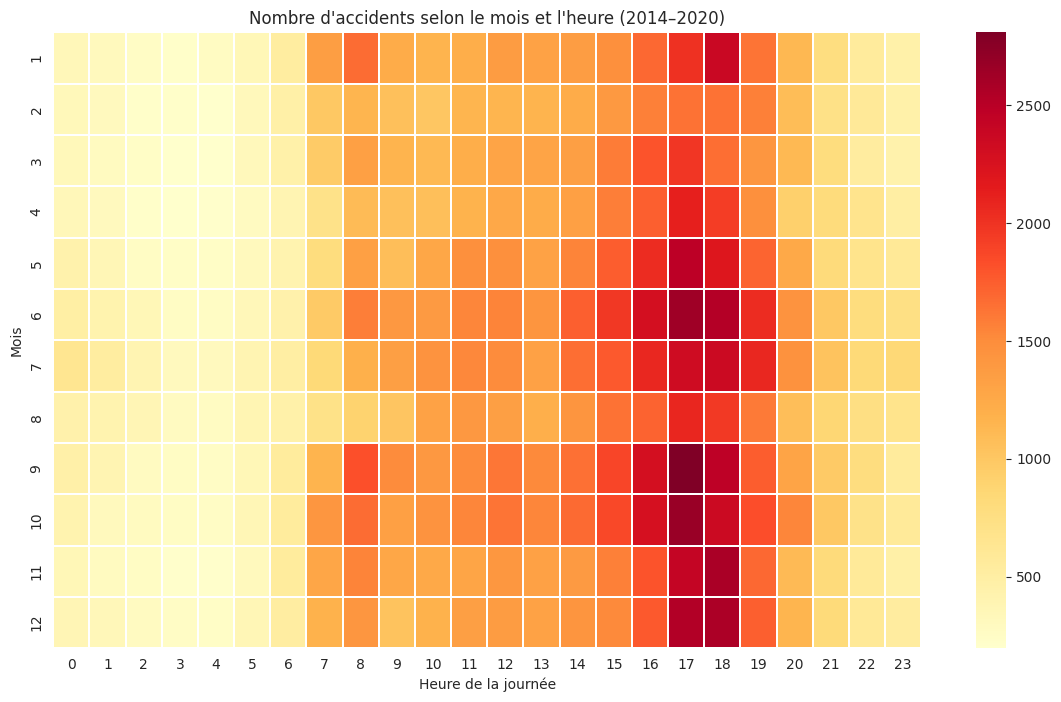

/tmp/ipykernel_767/3733423852.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=jour_counts.index,


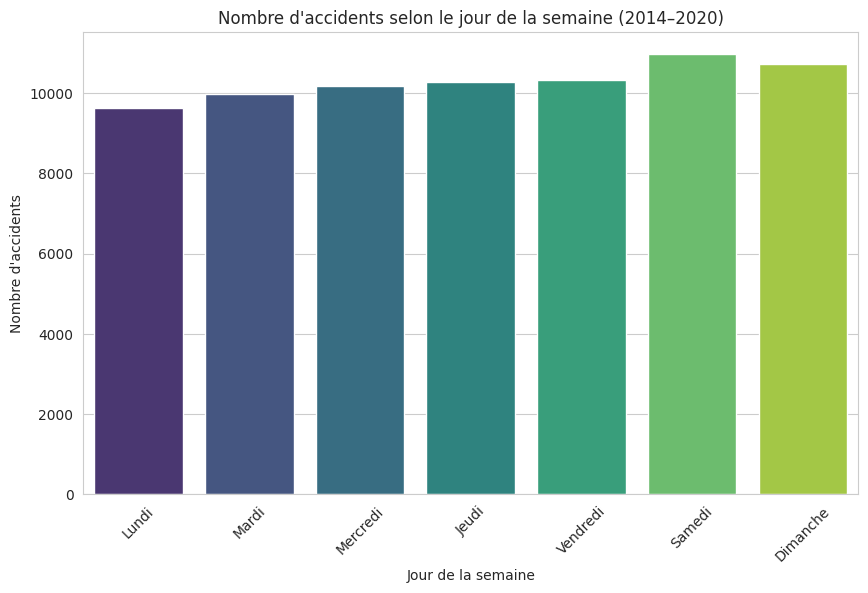

In [17]:
# --- Charger toutes les années ---
annees = [2014, 2015, 2016, 2017, 2018, 2020]
dfs = []

for annee in annees:
    df = pd.read_csv(f'caracteristiques_{annee}.csv',
                     encoding='latin1',
                     sep=';',
                     on_bad_lines='skip')
    dfs.append(df[['mois', 'jour', 'hrmn']])

df_all = pd.concat(dfs)

# --- Nettoyage heure ---
def extraire_heure(hrmn):
    try:
        hr_str = str(hrmn).zfill(4)  # complète à 4 chiffres
        heure = int(hr_str[:2])
        if 0 <= heure <= 23:
            return heure
        else:
            return None
    except:
        return None

df_all['heure'] = df_all['hrmn'].apply(extraire_heure)

# Supprimer les lignes avec heure ou mois manquant
df_all = df_all.dropna(subset=['heure', 'mois'])
df_all['heure'] = df_all['heure'].astype(int)
df_all['mois'] = df_all['mois'].astype(int)

# --- Nettoyage mois / jour ---
df_all = df_all[df_all['mois'].between(1, 12)]
df_all = df_all[df_all['heure'].between(0, 23)]

# =====================================================
# HEATMAP Mois × Heure
# =====================================================

heatmap_data = df_all.groupby(['mois', 'heure']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data,
            cmap="YlOrRd",
            linewidths=0.3)

plt.title("Nombre d'accidents selon le mois et l'heure (2014–2020)")
plt.xlabel("Heure de la journée")
plt.ylabel("Mois")
plt.show()

# =====================================================
# BARPLOT Jour de semaine
# =====================================================

jours_mapping = {
    1: "Lundi",
    2: "Mardi",
    3: "Mercredi",
    4: "Jeudi",
    5: "Vendredi",
    6: "Samedi",
    7: "Dimanche"
}

df_all['jour_nom'] = df_all['jour'].map(jours_mapping)

jour_counts = df_all['jour_nom'].value_counts().reindex(jours_mapping.values())

plt.figure(figsize=(10, 6))
sns.barplot(x=jour_counts.index,
            y=jour_counts.values,
            palette="viridis")

plt.title("Nombre d'accidents selon le jour de la semaine (2014–2020)")
plt.xlabel("Jour de la semaine")
plt.ylabel("Nombre d'accidents")
plt.xticks(rotation=45)
plt.show()

### Observations

- La majorité des accidents se produisent entre 7h et 20h, avec un pic marqué autour de 17h–18h, ce qui correspond aux heures de forte circulation.

- Selon les mois, la répartition reste relativement stable. Février présente un nombre légèrement inférieur, probablement à cause de sa durée plus courte. Mars et avril montrent aussi un peu moins d’accidents, mais toujours plus que février.

- Concernant les jours de la semaine, la distribution est assez homogène, avec un léger pic le samedi et un nombre un peu plus faible le lundi.

## 2.6. Influence de la localisation sur la gravité des accidents

Dans cette partie, nous analysons comment la localisation des accidents (hors agglomération vs en agglomération) affecte à la fois le nombre total d’accidents et la proportion d’accidents graves (tués ou blessés hospitalisés). L’objectif est de voir si la densité urbaine ou la circulation en ville vs campagne joue un rôle sur la gravité des accidents.

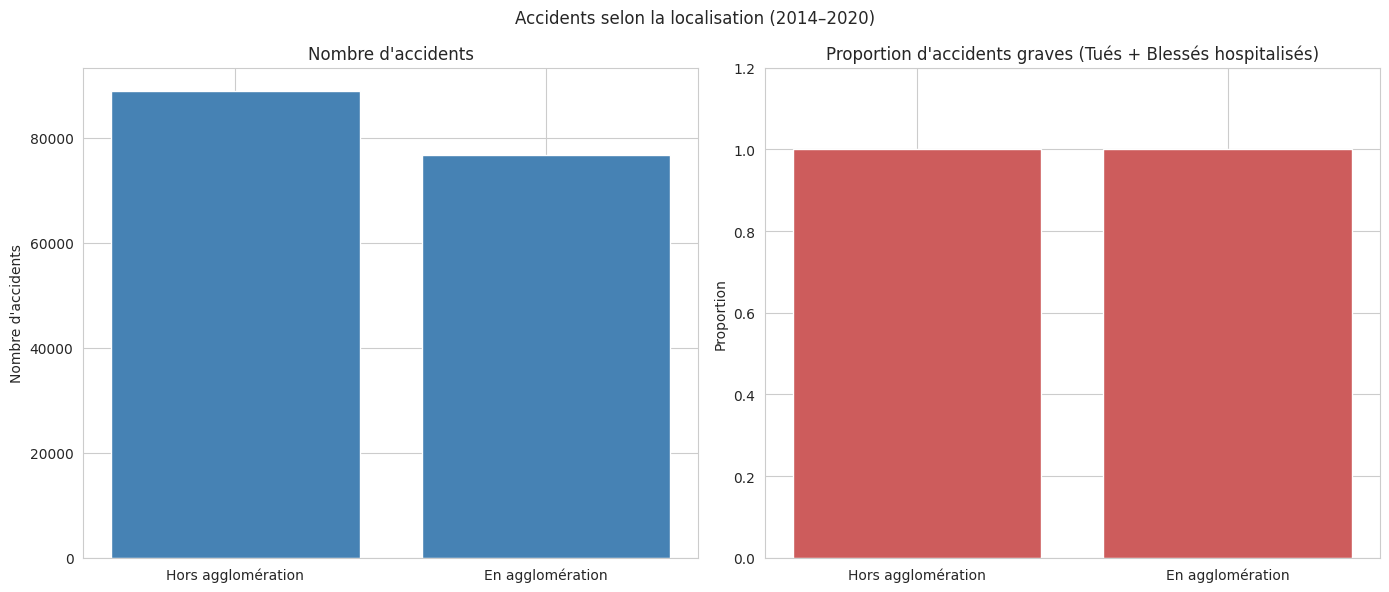

In [18]:
# --- Années à analyser ---
annees = [2014, 2015, 2016, 2017, 2018, 2020]

dfs = []
for annee in annees:
    df_carac = pd.read_csv(f'caracteristiques_{annee}.csv', encoding='latin1', sep=';', on_bad_lines='skip')
    df_usagers = pd.read_csv(f'usagers_{annee}.csv', encoding='latin1', sep=';', on_bad_lines='skip')

    # Assurer que Num_Acc est string pour le merge
    df_carac['Num_Acc'] = df_carac['Num_Acc'].astype(str)
    df_usagers['Num_Acc'] = df_usagers['Num_Acc'].astype(str)

    # Merge pour avoir 'grav'
    df_merged = pd.merge(df_carac[['Num_Acc', 'agg']], df_usagers[['Num_Acc', 'grav']], on='Num_Acc', how='inner')

    # Filtrer les valeurs invalides
    df_merged = df_merged[(df_merged['agg'].isin([1,2])) & (df_merged['grav'].isin([2,3]))]

    dfs.append(df_merged)

df_all = pd.concat(dfs)

# --- Nombre d'accidents ---
counts = df_all.groupby('agg')['Num_Acc'].count().reindex([1,2])

# --- Proportion d'accidents graves ---
prop_graves = df_all.groupby('agg')['grav'].count() / df_all.groupby('agg')['Num_Acc'].count()
prop_graves = prop_graves.reindex([1,2])

labels = ['Hors agglomération', 'En agglomération']

# --- Graphiques côte à côte ---
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Nombre d'accidents
axes[0].bar(labels, counts, color='steelblue')
axes[0].set_title("Nombre d'accidents")
axes[0].set_ylabel("Nombre d'accidents")

# Proportion d'accidents graves
axes[1].bar(labels, prop_graves, color='indianred')
axes[1].set_title("Proportion d'accidents graves (Tués + Blessés hospitalisés)")
axes[1].set_ylabel("Proportion")
axes[1].set_ylim(0, prop_graves.max()*1.2)

plt.suptitle("Accidents selon la localisation (2014–2020)")
plt.tight_layout()
plt.show()

### Observations

- Le nombre total d’accidents est plus élevé hors agglomération, ce qui correspond à une circulation sur route plus étendue et moins dense.

- En revanche, la proportion d’accidents graves est quasiment la même dans les deux cas. Les barres correspondantes sont presque à égalité, ce qui indique que la localisation en agglomération ou hors agglomération n’influence pas la gravité.

- Cela suggère que cette variable pourrait ne pas être particulièrement informative pour l’analyse de la gravité dans la suite de l’étude, même si elle est pertinente pour le nombre total d’accidents.

## Synthèse de la partie "Caractéristiques"

Après avoir exploré les différentes caractéristiques des accidents (conditions météo, luminosité, type de collision, département, horaires, localisation), plusieurs observations clés se dégagent :

Certaines variables semblent particulièrement informatives pour la gravité des accidents :

- **Luminosité et éclairage** : les accidents survenant la nuit sans éclairage public présentent une proportion plus élevée de blessés hospitalisés et de tués.

- **Type de collision** : les accidents “Sans collision” et les collisions frontales sont associés à des impacts graves plus fréquents.

- **Conditions météo extrêmes** : bien que rares, vent fort et brouillard apparaissent liés à une gravité légèrement plus élevée.

D’autres variables sont surtout utiles pour comprendre le volume total d’accidents, mais semblent moins déterminantes pour la gravité :

- **Départements très densément peuplés** : Paris, Rhône, Bouches-du-Rhône enregistrent beaucoup d’accidents, mais la proportion d’accidents graves y reste relativement faible.

- **Localisation en agglomération / hors agglomération** : la proportion d’accidents graves est très similaire, même si le nombre total varie.

- **Temporalité** : la majorité des accidents se produit entre 7h et 20h, avec un pic aux heures de forte circulation, mais la gravité n’est pas fortement concentrée sur une tranche horaire spécifique.

---

#### Conclusion de cette partie :

Les variables les plus prometteuses pour expliquer ou prédire la gravité semblent être la luminosité, le type de collision et certaines conditions météo extrêmes. Les autres variables, comme la localisation ou le volume par département, restent importantes pour comprendre le nombre total d’accidents mais apportent moins d’information pour la gravité.

# 3. Analyse des lieux des accidents

## 3.1. Répartition et gravité des accidents par catégorie de route
On peut s’interroger sur l’influence des différentes catégories de routes dans la répartition des accidents et de leur gravité. Ceux-ci sont-ils davantage présent et/ou grave sur les autoroutes en raison des vitesses élevées pratiquées, ou plutôt sur les voies communales, où le trafic est plus dense et multidirectionnel ? Ces graphiques permettent ainsi de visualiser et d’analyser la distribution des accidents et leur gravité selon le type de route afin de mieux comprendre ces dynamiques.

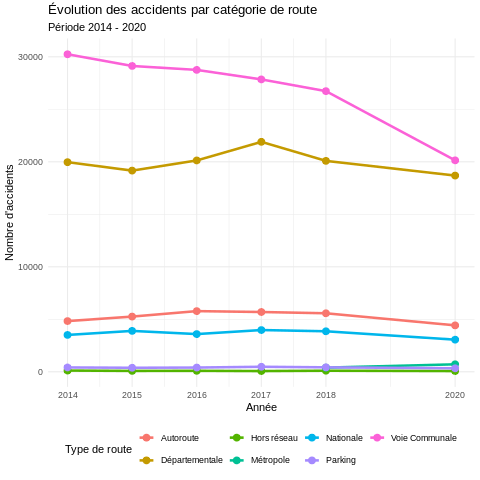

In [19]:
%%R

# 1. Liste des fichiers
fichiers <- c(
  "lieux_2014.csv", "lieux_2015.csv", "lieux_2016.csv",
  "lieux_2017.csv", "lieux_2018.csv", "lieux_2020.csv"
)

# 2. Fonction de lecture robuste
lire_data_robuste <- function(nom_fichier) {
  read_delim(
    nom_fichier,
    delim = NULL,                     # Détection automatique du séparateur
    col_types = cols(.default = "c"), # Tout en texte
    show_col_types = FALSE
  )
}

# 3. Fusion
df_accidents <- fichiers %>%
  set_names() %>%
  map_df(~lire_data_robuste(.), .id = "nom_fichier")

# 4. Nettoyage
df_accidents <- df_accidents %>%
  mutate(
    annee = as.numeric(str_extract(nom_fichier, "\\d{4}")),
    catr  = as.numeric(catr),
    surf  = as.numeric(surf)
  )

# --- GRAPHIQUE 1 : Catégorie de route ---

labels_route <- c(
  "1" = "Autoroute",
  "2" = "Nationale",
  "3" = "Départementale",
  "4" = "Voie Communale",
  "5" = "Hors réseau",
  "6" = "Parking",
  "7" = "Métropole",
  "9" = "Autre"
)

df_graph <- df_accidents %>%
  mutate(cat_label = labels_route[catr]) %>%
  filter(!is.na(cat_label)) %>%
  group_by(annee, cat_label) %>%
  summarise(total = n(), .groups = "drop")

ggplot(df_graph, aes(x = annee, y = total, color = cat_label)) +
  geom_line(linewidth = 1.2) +
  geom_point(size = 3) +
  scale_x_continuous(breaks = c(2014, 2015, 2016, 2017, 2018, 2020)) +
  labs(
    title    = "Évolution des accidents par catégorie de route",
    subtitle = "Période 2014 - 2020",
    x        = "Année",
    y        = "Nombre d'accidents",
    color    = "Type de route"
  ) +
  theme_minimal() +
  theme(legend.position = "bottom")


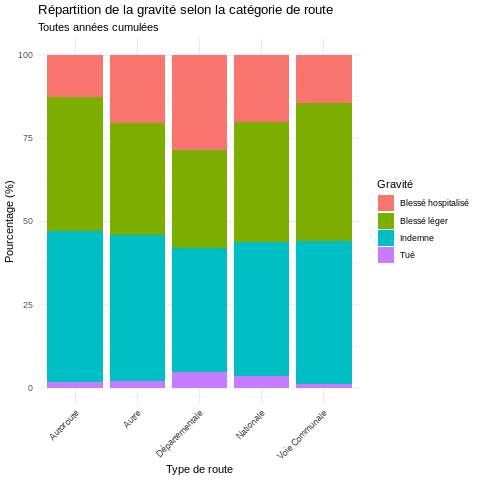

In [20]:
%%R

# -------------------------
# 1. Lecture des fichiers usagers
# -------------------------
fichiers_usagers <- c("usagers_2014.csv", "usagers_2015.csv", "usagers_2016.csv",
                      "usagers_2017.csv", "usagers_2018.csv", "usagers_2020.csv")

lire_data_robuste <- function(nom_fichier) {
  read_delim(
    nom_fichier,
    delim = ";",
    col_types = cols(.default = "c"),
    show_col_types = FALSE
  )
}

df_usagers <- fichiers_usagers %>%
  set_names() %>%
  map_df(~lire_data_robuste(.), .id = "nom_fichier")

# -------------------------
# 2. Nettoyage et regroupement gravité
# -------------------------
df_usagers <- df_usagers %>%
  mutate(
    grav = as.numeric(grav),
    grav_label = case_when(
      grav == 1 ~ "Indemne",
      grav == 2 ~ "Tué",
      grav == 3 ~ "Blessé hospitalisé",
      grav == 4 ~ "Blessé léger",
      TRUE ~ "Inconnu"
    )
  ) %>%
  filter(!is.na(grav))

# -------------------------
# 3. Ajouter catégorie de route depuis df_accidents
# -------------------------
labels_route <- c(
  "1" = "Autoroute", "2" = "Nationale", "3" = "Départementale",
  "4" = "Voie Communale", "5" = "Hors réseau", "6" = "Parking",
  "7" = "Métropole", "9" = "Autre"
)

df_usagers_route <- df_usagers %>%
  left_join(
    df_accidents %>%
      mutate(
        cat_label = labels_route[catr],
        # Regroupement des petites catégories en "Autre"
        cat_label = ifelse(cat_label %in% c("Hors réseau","Parking","Métropole"), "Autre", cat_label)
      ) %>%
      select(Num_Acc, cat_label),
    by = "Num_Acc"
  ) %>%
  filter(!is.na(cat_label))

# -------------------------
# 4. Calcul des pourcentages par catégorie de route
# -------------------------
df_graph2 <- df_usagers_route %>%
  group_by(cat_label, grav_label) %>%
  summarise(nombre = n(), .groups = "drop") %>%
  group_by(cat_label) %>%
  mutate(pourcentage = nombre / sum(nombre) * 100) %>%
  ungroup()

# -------------------------
# 5. Graphique : répartition gravité par catégorie de route
# -------------------------
ggplot(df_graph2, aes(x = cat_label, y = pourcentage, fill = grav_label)) +
  geom_bar(stat = "identity", position = "stack") +
  labs(
    title = "Répartition de la gravité selon la catégorie de route",
    subtitle = "Toutes années cumulées",
    x = "Type de route",
    y = "Pourcentage (%)",
    fill = "Gravité"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

### Observations

Le premier graphique met en évidence que, dans notre jeu de données, les accidents surviennent majoritairement sur les voies communales et les routes départementales. Viennent ensuite les routes nationales, puis les autoroutes.

Si l’on peut penser que la vitesse élevée sur autoroute entraîne davantage d’accidents, les données montrent que ce sont surtout les axes les plus nombreux et les plus fréquentés au quotidien qui concentrent la majorité des sinistres. Les voies communales et départementales représentent en effet près de 90 % du réseau routier français, ce qui augmente mécaniquement l’exposition au risque.

De plus, ces routes se caractérisent souvent par un trafic multidirectionnel, des intersections fréquentes, la présence de piétons ou de cyclistes et des conditions de circulation plus variables. À l’inverse, les autoroutes, bien que plus rapides, sont généralement mieux sécurisées (séparation des voies, absence de carrefours, accès réglementé), ce qui peut limiter le nombre d’accidents.
En 2020, ce sont surtout les voies communales qui ont enregistré une baisse significative des accidents, probablement parce que ce type de route était moins fréquenté pendant le confinement.

---

Concernant le deuxième graphique, qui met en relation la gravité des accidents et le type de route, on observe que la vitesse pratiquée sur les autoroutes ne semble pas avoir un impact direct sur la gravité des accidents. En effet, le nombre de blessés hospitalisés et de tués y reste relativement faible.

Les routes départementales constituent le deuxième type de route où l’on recense le plus d’accidents, mais ce sont celles où l’on observe la proportion la plus importante d’accidents graves (blessés hospitalisés et tués).

Quant aux voies communales, elles enregistrent principalement des blessés légers et des usagers indemnes, ce qui est sans doute proportionnel à leur volume global d’accidents.

## 3.2. Analyse des accidents et de leur gravité selon l'état de la surface

Nous nous intéressons à la répartition des accidents selon l'état de la surface de la route, afin de déterminer si certains types de surfaces sont associés à une fréquence ou à une gravité particulière des accidents.

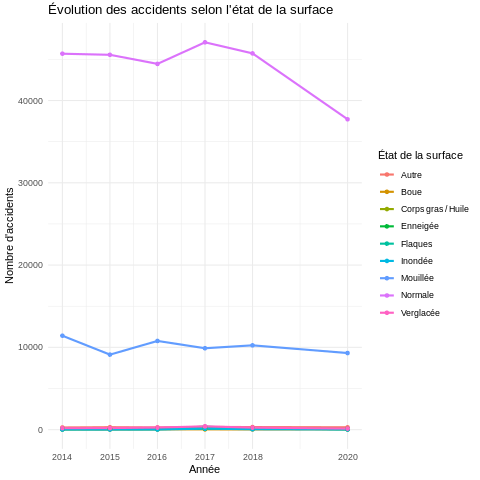

In [38]:
%%R

# 1. Liste des fichiers
fichiers <- c("lieux_2014.csv", "lieux_2015.csv", "lieux_2016.csv",
              "lieux_2017.csv", "lieux_2018.csv", "lieux_2020.csv")

# 2. Lecture robuste
df_accidents <- fichiers %>%
  set_names() %>%
  map_df(~read_delim(.,
                     delim = NULL,
                     col_types = cols(.default = "c"),
                     show_col_types = FALSE),
         .id = "source")

# 3. Dictionnaire pour 'surf'
labels_surf <- c(
  "1" = "Normale",
  "2" = "Mouillée",
  "3" = "Flaques",
  "4" = "Inondée",
  "5" = "Enneigée",
  "6" = "Boue",
  "7" = "Verglacée",
  "8" = "Corps gras / Huile",
  "9" = "Autre"
)

# 4. Nettoyage
df_surf_evol <- df_accidents %>%
  mutate(
    annee = as.numeric(str_extract(source, "\\d{4}")),
    surf = suppressWarnings(as.numeric(surf)),
    surf = ifelse(surf %in% 1:9, surf, NA),
    surf_label = labels_surf[as.character(surf)]
  ) %>%
  filter(!is.na(surf_label)) %>%
  group_by(annee, surf_label) %>%
  summarise(nb_accidents = n(), .groups = "drop")

# --- GRAPHIQUE 1 : lignes par état de surface ---
ggplot(df_surf_evol, aes(x = annee, y = nb_accidents, color = surf_label)) +
  geom_line(linewidth = 1) +
  geom_point() +
  scale_x_continuous(breaks = unique(df_surf_evol$annee)) +
  labs(
    title = "Évolution des accidents selon l'état de la surface",
    x = "Année",
    y = "Nombre d'accidents",
    color = "État de la surface"
  ) +
  theme_minimal()


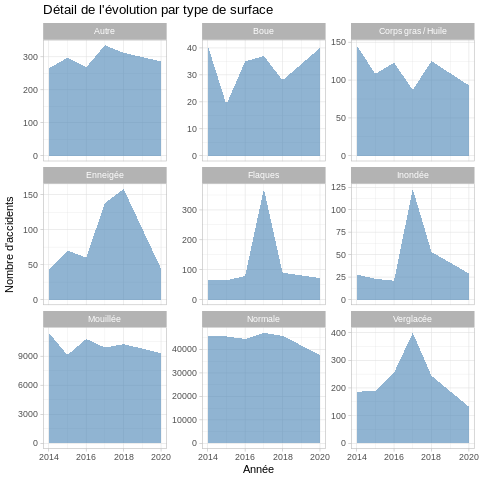

In [40]:
%%R

# 1. Liste des fichiers
fichiers <- c("lieux_2014.csv", "lieux_2015.csv", "lieux_2016.csv",
              "lieux_2017.csv", "lieux_2018.csv", "lieux_2020.csv")

# 2. Lecture robuste
df_accidents <- fichiers %>%
  set_names() %>%
  map_df(~read_delim(.,
                     delim = NULL,
                     col_types = cols(.default = "c"),
                     show_col_types = FALSE),
         .id = "source")

# 3. Dictionnaire pour 'surf'
labels_surf <- c(
  "1" = "Normale",
  "2" = "Mouillée",
  "3" = "Flaques",
  "4" = "Inondée",
  "5" = "Enneigée",
  "6" = "Boue",
  "7" = "Verglacée",
  "8" = "Corps gras / Huile",
  "9" = "Autre"
)

# 4. Nettoyage
df_surf_evol <- df_accidents %>%
  mutate(
    annee = as.numeric(str_extract(source, "\\d{4}")),
    surf = suppressWarnings(as.numeric(surf)),
    surf = ifelse(surf %in% 1:9, surf, NA),
    surf_label = labels_surf[as.character(surf)]
  ) %>%
  filter(!is.na(surf_label)) %>%
  group_by(annee, surf_label) %>%
  summarise(nb_accidents = n(), .groups = "drop")

# --- GRAPHIQUE 2 : facettes ---
ggplot(df_surf_evol, aes(x = annee, y = nb_accidents)) +
  geom_area(fill = "steelblue", alpha = 0.6) +
  facet_wrap(~surf_label, scales = "free_y") +
  labs(
    title = "Détail de l'évolution par type de surface",
    x = "Année",
    y = "Nombre d'accidents"
  ) +
  theme_light()


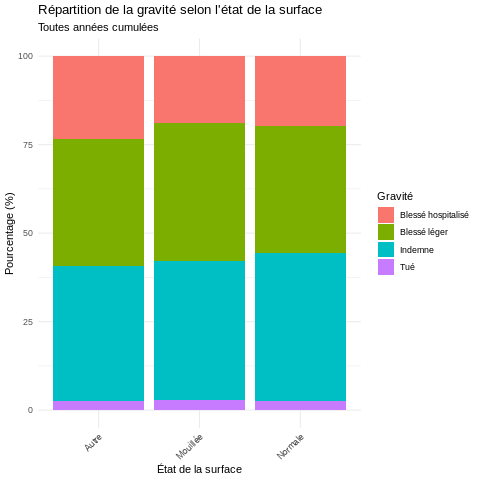

In [41]:
%%R

# -------------------------
# 1. Lecture fichiers lieux
# -------------------------
fichiers_lieux <- c("lieux_2014.csv", "lieux_2015.csv", "lieux_2016.csv",
                    "lieux_2017.csv", "lieux_2018.csv", "lieux_2020.csv")

df_accidents <- fichiers_lieux %>%
  set_names() %>%
  map_df(~read_delim(.,
                     delim = NULL,
                     col_types = cols(.default = "c"),
                     show_col_types = FALSE),
         .id = "source") %>%
  mutate(
    surf = suppressWarnings(as.numeric(surf)),
    surf_label = case_when(
      surf == 1 ~ "Normale",
      surf == 2 ~ "Mouillée",
      TRUE ~ "Autre"
    )
  ) %>%
  select(Num_Acc, surf_group = surf_label)  # on garde Num_Acc pour le join

# -------------------------
# 2. Lecture fichiers usagers
# -------------------------
fichiers_usagers <- c("usagers_2014.csv", "usagers_2015.csv", "usagers_2016.csv",
                      "usagers_2017.csv", "usagers_2018.csv", "usagers_2020.csv")

df_usagers <- fichiers_usagers %>%
  set_names() %>%
  map_df(~read_delim(.,
                     delim = ";",
                     col_types = cols(.default = "c"),
                     show_col_types = FALSE),
         .id = "source") %>%
  mutate(
    grav = as.numeric(grav),
    grav_label = case_when(
      grav == 1 ~ "Indemne",
      grav == 2 ~ "Tué",
      grav == 3 ~ "Blessé hospitalisé",
      grav == 4 ~ "Blessé léger",
      TRUE ~ "Inconnu"
    )
  ) %>%
  filter(!is.na(grav_label)) %>%
  select(Num_Acc, grav_label)

# -------------------------
# 3. Jointure sur Num_Acc
# -------------------------
df_join <- df_usagers %>%
  left_join(df_accidents, by = "Num_Acc") %>%
  filter(!is.na(surf_group))

# -------------------------
# 4. Calcul pourcentages
# -------------------------
df_graph <- df_join %>%
  group_by(surf_group, grav_label) %>%
  summarise(nombre = n(), .groups = "drop") %>%
  group_by(surf_group) %>%
  mutate(pourcentage = nombre / sum(nombre) * 100) %>%
  ungroup()

# -------------------------
# 5. Graphique
# -------------------------
ggplot(df_graph, aes(x = surf_group, y = pourcentage, fill = grav_label)) +
  geom_bar(stat = "identity", position = "stack") +
  labs(
    title = "Répartition de la gravité selon l'état de la surface",
    subtitle = "Toutes années cumulées",
    x = "État de la surface",
    y = "Pourcentage (%)",
    fill = "Gravité"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

### Observations

- La surface normale est largement majoritaire dans les accidents, avec environ 45 000 accidents par an sur la période étudiée. On note une baisse notable en 2020, avec moins de 40 000 accidents, probablement liée aux conditions météo favorables pendant la période du confinement.

- La surface mouillée représente un volume beaucoup plus faible, stable autour de 10 000 accidents par an pour toutes les années.

- Les autres surfaces (flaques, boue, corps gras/huile, enneigée, inondée, verglacée) sont très minoritaires, avec des accidents qui se comptent seulement par centaines, voire par dizaines. Sur le graphique détaillé par type de surface, ces catégories apparaissent donc comme des courbes très instables. Le « pic » observé en 2017 dans ces catégories est en réalité peu significatif : il correspond à un petit nombre d’accidents et peut refléter simplement un remplissage plus précis des données cette année-là.

- Concernant la gravité des accidents, les différences entre types de surface sont faibles. En regroupant les catégories minoritaires dans Autre pour avoir suffisamment de données par groupe, on constate que la proportion de blessés légers, blessés hospitalisés ou tués ne varie pas de manière marquée selon l’état de la surface.

- Il est important de nuancer toute interprétation : la surface normale étant beaucoup plus fréquente que mouillée, le nombre d’accidents y est plus élevé simplement par exposition. On ne peut donc pas conclure qu’une surface mouillée entraîne proportionnellement plus d’accidents graves que la surface normale.

## 3.3. Influence du tracé de la route sur la survenue d'accidents et leur gravité

Cette partie s’intéresse à la relation entre le tracé de la route et la survenue des accidents, ainsi qu’à leur gravité. Les routes sont regroupées en quatre catégories : *Ligne droite*, *Courbe à gauche*, *Courbe à droite* et *En S*.

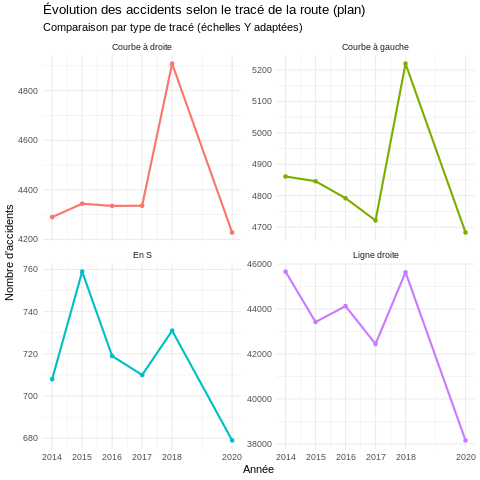

In [42]:
%%R

# 1. Liste des fichiers
fichiers <- c("lieux_2014.csv", "lieux_2015.csv", "lieux_2016.csv",
              "lieux_2017.csv", "lieux_2018.csv", "lieux_2020.csv")

# 2. Lecture robuste
df_accidents <- fichiers %>%
  set_names() %>%
  map_df(~read_delim(.,
                     delim = NULL,
                     col_types = cols(.default = "c"),
                     show_col_types = FALSE),
         .id = "source")

# 3. Dictionnaire pour la variable 'plan'
labels_plan <- c(
  "1" = "Ligne droite",
  "2" = "Courbe à gauche",
  "3" = "Courbe à droite",
  "4" = "En S"
)

# 4. Nettoyage robuste
df_plan_evol <- df_accidents %>%
  mutate(
    annee = as.numeric(str_extract(source, "\\d{4}")),
    plan_clean = str_replace_all(plan, "[^0-9]", ""),   # enlève espaces, parenthèses, etc.
    plan_clean = ifelse(plan_clean %in% c("1","2","3","4"), plan_clean, NA),
    plan_label = labels_plan[plan_clean]
  ) %>%
  filter(!is.na(plan_label)) %>%
  group_by(annee, plan_label) %>%
  summarise(nb_accidents = n(), .groups = "drop")

# 5. Graphique avec facettes
ggplot(df_plan_evol, aes(x = annee, y = nb_accidents, color = plan_label)) +
  geom_line(linewidth = 1) +
  geom_point() +
  facet_wrap(~plan_label, scales = "free_y") +
  scale_x_continuous(breaks = c(2014, 2015, 2016, 2017, 2018, 2020)) +
  labs(
    title = "Évolution des accidents selon le tracé de la route (plan)",
    subtitle = "Comparaison par type de tracé (échelles Y adaptées)",
    x = "Année",
    y = "Nombre d'accidents",
    color = "Type de tracé"
  ) +
  theme_minimal() +
  theme(legend.position = "none")


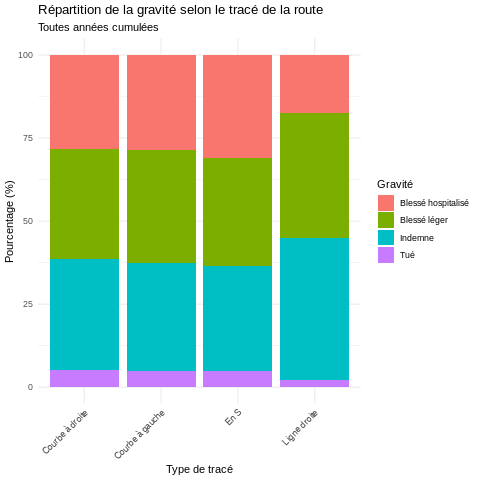

In [43]:
%%R

# -------------------------
# 1. Lecture fichiers lieux
# -------------------------
fichiers_lieux <- c("lieux_2014.csv", "lieux_2015.csv", "lieux_2016.csv",
                    "lieux_2017.csv", "lieux_2018.csv", "lieux_2020.csv")

df_accidents <- fichiers_lieux %>%
  set_names() %>%
  map_df(~read_delim(.,
                     delim = NULL,
                     col_types = cols(.default = "c"),
                     show_col_types = FALSE),
         .id = "source") %>%
  mutate(
    plan_clean = str_replace_all(plan, "[^0-9]", ""),
    plan_clean = ifelse(plan_clean %in% c("1","2","3","4"), plan_clean, NA),
    plan_label = case_when(
      plan_clean == "1" ~ "Ligne droite",
      plan_clean == "2" ~ "Courbe à gauche",
      plan_clean == "3" ~ "Courbe à droite",
      plan_clean == "4" ~ "En S",
      TRUE ~ NA_character_
    )
  ) %>%
  select(Num_Acc, plan_label) %>%
  filter(!is.na(plan_label))

# -------------------------
# 2. Lecture fichiers usagers
# -------------------------
fichiers_usagers <- c("usagers_2014.csv", "usagers_2015.csv", "usagers_2016.csv",
                      "usagers_2017.csv", "usagers_2018.csv", "usagers_2020.csv")

df_usagers <- fichiers_usagers %>%
  set_names() %>%
  map_df(~read_delim(.,
                     delim = ";",
                     col_types = cols(.default = "c"),
                     show_col_types = FALSE),
         .id = "source") %>%
  mutate(
    grav = as.numeric(grav),
    grav_label = case_when(
      grav == 1 ~ "Indemne",
      grav == 2 ~ "Tué",
      grav == 3 ~ "Blessé hospitalisé",
      grav == 4 ~ "Blessé léger",
      TRUE ~ "Inconnu"
    )
  ) %>%
  filter(!is.na(grav_label)) %>%
  select(Num_Acc, grav_label)

# -------------------------
# 3. Jointure sur Num_Acc
# -------------------------
df_join <- df_usagers %>%
  left_join(df_accidents, by = "Num_Acc") %>%
  filter(!is.na(plan_label))

# -------------------------
# 4. Calcul pourcentages
# -------------------------
df_graph <- df_join %>%
  group_by(plan_label, grav_label) %>%
  summarise(nombre = n(), .groups = "drop") %>%
  group_by(plan_label) %>%
  mutate(pourcentage = nombre / sum(nombre) * 100) %>%
  ungroup()

# -------------------------
# 5. Graphique
# -------------------------
ggplot(df_graph, aes(x = plan_label, y = pourcentage, fill = grav_label)) +
  geom_bar(stat = "identity", position = "stack") +
  labs(
    title = "Répartition de la gravité selon le tracé de la route",
    subtitle = "Toutes années cumulées",
    x = "Type de tracé",
    y = "Pourcentage (%)",
    fill = "Gravité"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

### Observations

- On observe globalement une baisse du nombre d’accidents en 2020 pour tous les types de tracé, probablement liée au confinement et aux conditions de circulation réduites.

- Les courbes à gauche et à droite présentent un pic en 2018, comptant chacune entre 4 000 et un peu plus de 5 000 accidents. L’explication précise de ce pic n’est pas claire, il peut s’agir de variations locales dans le remplissage des données ou de conditions particulières cette année-là.

- Le tracé en S reste le moins fréquent, avec environ 680 à 760 accidents par an.

- Les lignes droites concentrent de loin le plus grand nombre d’accidents, fluctuant autour de 40 000 à 46 000 par an, sauf en 2020 où elles descendent à environ 38 000 accidents.

- Concernant la gravité des accidents, la ligne droite se distingue nettement : elle présente beaucoup moins de tués et de blessés hospitalisés que les autres types de tracé, avec une majorité d’indemnes.

- Les tracés en courbe (à gauche, à droite ou en S), où la visibilité est généralement réduite et la trajectoire plus complexe, semblent associés à des accidents plus graves, avec une proportion plus élevée de tués et de blessés hospitalisés par rapport aux lignes droites.

- Cette observation suggère que la configuration de la route peut jouer un rôle dans la gravité des accidents, même si le nombre absolu d’accidents reste largement dominé par les lignes droites en raison de leur fréquence.

## 3.4. Analyse des accidents et de leur gravité selon l'infrastructure

Nous analysons ici le lien entre le type d’infrastructure routière et la survenue des accidents, ainsi que leur gravité. L’objectif est d’identifier si certains aménagements (ponts, tunnels, carrefours, etc.) sont associés à un volume ou à une sévérité particulière des accidents.

`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


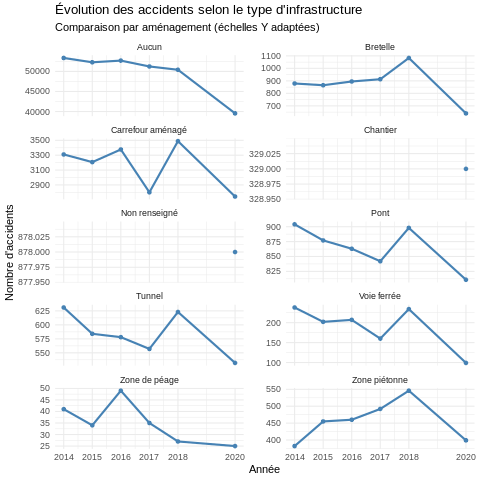

In [44]:
%%R

# -------------------------
# 1. Liste des fichiers
# -------------------------
fichiers <- c("lieux_2014.csv", "lieux_2015.csv", "lieux_2016.csv",
              "lieux_2017.csv", "lieux_2018.csv", "lieux_2020.csv")

# -------------------------
# 2. Lecture robuste
# -------------------------
df_accidents <- fichiers %>%
  set_names() %>%
  map_df(~read_delim(.,
                     delim = NULL,
                     col_types = cols(.default = "c"),
                     show_col_types = FALSE),
         .id = "source")

# -------------------------
# 3. Dictionnaire infra
# -------------------------
labels_infra <- c(
  "-1" = "Non renseigné",
  "0"  = "Aucun",
  "1"  = "Tunnel",
  "2"  = "Pont",
  "3"  = "Bretelle",
  "4"  = "Voie ferrée",
  "5"  = "Carrefour aménagé",
  "6"  = "Zone piétonne",
  "7"  = "Zone de péage",
  "8"  = "Chantier"
)

# -------------------------
# 4. Nettoyage
# -------------------------
df_infra_evol <- df_accidents %>%
  mutate(
    annee = as.numeric(str_extract(source, "\\d{4}")),
    infra_clean = str_replace_all(infra, "[^0-9-]", ""),
    infra_clean = ifelse(infra_clean %in% names(labels_infra), infra_clean, NA),
    infra_label = labels_infra[infra_clean]
  ) %>%
  filter(!is.na(infra_label)) %>%
  group_by(annee, infra_label) %>%
  summarise(nb_accidents = n(), .groups = "drop")

# -------------------------
# 5. Graphique avec facettes
# -------------------------
ggplot(df_infra_evol, aes(x = annee, y = nb_accidents)) +
  geom_line(color = "steelblue", linewidth = 1) +
  geom_point(color = "steelblue") +
  facet_wrap(~infra_label, scales = "free_y", ncol=2) +
  scale_x_continuous(breaks = c(2014, 2015, 2016, 2017, 2018, 2020)) +
  labs(
    title = "Évolution des accidents selon le type d'infrastructure",
    subtitle = "Comparaison par aménagement (échelles Y adaptées)",
    x = "Année",
    y = "Nombre d'accidents"
  ) +
  theme_minimal()

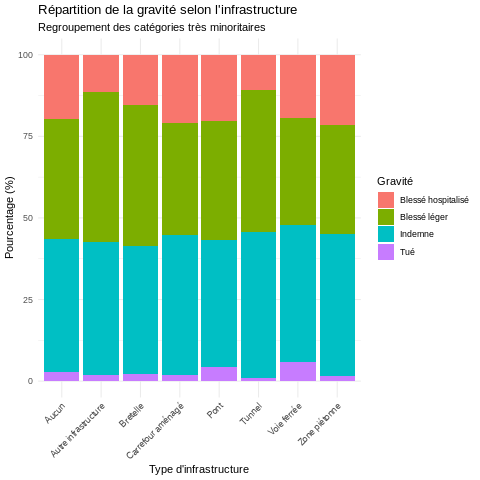

In [45]:
%%R

# -------------------------
# 1. Lecture fichiers lieux
# -------------------------
fichiers_lieux <- c("lieux_2014.csv", "lieux_2015.csv", "lieux_2016.csv",
                    "lieux_2017.csv", "lieux_2018.csv", "lieux_2020.csv")

labels_infra <- c(
  "-1" = "Non renseigné",
  "0"  = "Aucun",
  "1"  = "Tunnel",
  "2"  = "Pont",
  "3"  = "Bretelle",
  "4"  = "Voie ferrée",
  "5"  = "Carrefour aménagé",
  "6"  = "Zone piétonne",
  "7"  = "Zone de péage",
  "8"  = "Chantier"
)

df_accidents <- fichiers_lieux %>%
  set_names() %>%
  map_df(~read_delim(.,
                     delim = NULL,
                     col_types = cols(.default = "c"),
                     show_col_types = FALSE),
         .id = "source") %>%
  mutate(
    infra_clean = str_replace_all(infra, "[^0-9-]", ""),
    infra_clean = ifelse(infra_clean %in% names(labels_infra), infra_clean, NA),
    infra_label = labels_infra[infra_clean],

    # 🔹 Regroupement des petites catégories
    infra_group = case_when(
      infra_label %in% c("Non renseigné", "Chantier", "Zone de péage") ~ "Autre infrastructure",
      TRUE ~ infra_label
    )
  ) %>%
  select(Num_Acc, infra_group) %>%
  filter(!is.na(infra_group))

# -------------------------
# 2. Lecture fichiers usagers (gravité)
# -------------------------
fichiers_usagers <- c("usagers_2014.csv", "usagers_2015.csv", "usagers_2016.csv",
                      "usagers_2017.csv", "usagers_2018.csv", "usagers_2020.csv")

df_usagers <- fichiers_usagers %>%
  set_names() %>%
  map_df(~read_delim(.,
                     delim = ";",
                     col_types = cols(.default = "c"),
                     show_col_types = FALSE),
         .id = "source") %>%
  mutate(
    grav = as.numeric(grav),
    grav_label = case_when(
      grav == 1 ~ "Indemne",
      grav == 2 ~ "Tué",
      grav == 3 ~ "Blessé hospitalisé",
      grav == 4 ~ "Blessé léger",
      TRUE ~ "Inconnu"
    )
  ) %>%
  filter(!is.na(grav_label)) %>%
  select(Num_Acc, grav_label)

# -------------------------
# 3. Jointure
# -------------------------
df_join <- df_usagers %>%
  left_join(df_accidents, by = "Num_Acc") %>%
  filter(!is.na(infra_group))

# -------------------------
# 4. Calcul des pourcentages
# -------------------------
df_graph <- df_join %>%
  group_by(infra_group, grav_label) %>%
  summarise(nombre = n(), .groups = "drop") %>%
  group_by(infra_group) %>%
  mutate(pourcentage = nombre / sum(nombre) * 100) %>%
  ungroup()

# -------------------------
# 5. Graphique
# -------------------------
ggplot(df_graph, aes(x = infra_group, y = pourcentage, fill = grav_label)) +
  geom_bar(stat = "identity", position = "stack") +
  labs(
    title = "Répartition de la gravité selon l'infrastructure",
    subtitle = "Regroupement des catégories très minoritaires",
    x = "Type d'infrastructure",
    y = "Pourcentage (%)",
    fill = "Gravité"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

### Observations

- La répartition des accidents selon l’infrastructure est très inégale. La catégorie “Aucun” domine très largement : entre 2014 et 2018, elle enregistre plus de 50 000 accidents par an, avec une baisse à environ 40 000 en 2020.

- Les autres catégories restent très minoritaires. Les accidents en zone de péage varient entre 25 et 50 par an seulement. Les catégories comme pont, voie ferrée, bretelle ou carrefour aménagé se comptent en centaines d’accidents annuels.

- En 2020 apparaissent davantage de cas “*Non renseigné*” et “*Chantier*”, ce qui peut reflète une modification du remplissage plutôt qu’un phénomène structurel.

- Cette forte inégalité peut s’expliquer en partie par la structure du réseau routier : la majorité des routes ne comportent pas d’aménagement particulier, ce qui explique la domination de la catégorie “Aucun”.

## Synthèse de la partie "Lieux"

Dans cette partie, nous avons analysé les caractéristiques liées au lieu de l’accident : type de route, état de la surface, tracé et infrastructure. L’objectif était d’identifier si certaines configurations de l’environnement routier influencent le nombre d’accidents et leur gravité.

#### Observations principales :

- **Type de route**

  - Les accidents surviennent majoritairement sur les voies communales et les routes départementales, qui représentent la plus grande part du réseau routier et concentrent donc mécaniquement davantage d’exposition au risque.

  - Les autoroutes enregistrent moins d’accidents en volume, malgré des vitesses plus élevées, probablement grâce à des infrastructures plus sécurisées (séparation des voies, absence d’intersections, accès réglementé).

  - En termes de gravité, les routes départementales présentent proportionnellement davantage d’accidents graves (blessés hospitalisés et tués), tandis que les voies communales comptent surtout des blessés légers et des indemnes.

  - Une baisse marquée des accidents apparaît en 2020, notamment sur les voies communales, probablement liée à la diminution du trafic pendant le confinement.

- **Etat de la surface**

  - La surface normale est largement majoritaire et concentre la grande majorité des accidents (environ 45 000 par an avant 2020).

  - La surface mouillée représente un volume bien plus faible mais relativement stable au fil des années.

  - Les autres états de surface (verglas, neige, boue, flaques, huile, inondation) restent très minoritaires et présentent des variations annuelles peu interprétables en raison de leurs faibles effectifs.

  - Concernant la gravité, aucune différence nette n’apparaît entre surface normale, mouillée ou autres. Les écarts observés semblent davantage liés au volume d’exposition qu’à un effet propre de l’état de la chaussée.

- **Tracé de la route**

  - Les lignes droites concentrent de loin le plus grand nombre d’accidents, ce qui s’explique par leur fréquence dans le réseau routier.

  - Les courbes (à gauche, à droite ou en S), bien que moins fréquentes, semblent associées à une proportion plus élevée d’accidents graves (blessés hospitalisés et tués).

  - Cela suggère que la configuration géométrique de la route (visibilité réduite, trajectoire plus complexe) pourrait jouer un rôle dans la gravité des accidents, même si le volume total reste dominé par les lignes droites.

- **Infrastructure**

  - La catégorie “Aucun aménagement” domine très largement, avec plus de 50 000 accidents annuels entre 2014 et 2018.

  - Les autres infrastructures (pont, voie ferrée, bretelle, carrefour aménagé) restent très minoritaires, souvent limitées à quelques centaines d’accidents par an.

  - Les différences de gravité entre infrastructures ne sont pas marquées. Une proportion légèrement plus élevée de décès semble apparaître pour les ponts et les voies ferrées, mais les effectifs restent faibles, ce qui limite la robustesse de cette observation.

  - L’apparition de catégories comme “Non renseigné” ou “Chantier” en 2020 suggère une évolution du remplissage des données plutôt qu’un changement structurel majeur.

#### Conclusion et intérêt pour l’analyse de la gravité

Les variables liées aux lieux montrent surtout un effet d’exposition : les catégories les plus fréquentes dans le réseau routier concentrent logiquement le plus grand nombre d’accidents.

# 4. Analyse des véhicules impliqués dans les accidents

## 4.1. Influence des obstacles fixes et mobiles sur la gravité des accidents

Dans cette partie, nous nous intéressons à la table vehicules afin d’analyser le rôle des obstacles rencontrés dans la gravité des accidents.

/tmp/ipykernel_767/3206839089.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(obs_fix['label'], rotation=45, ha='right')
/tmp/ipykernel_767/3206839089.py:88: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(obs_mob['obsm_group'], rotation=45, ha='right')


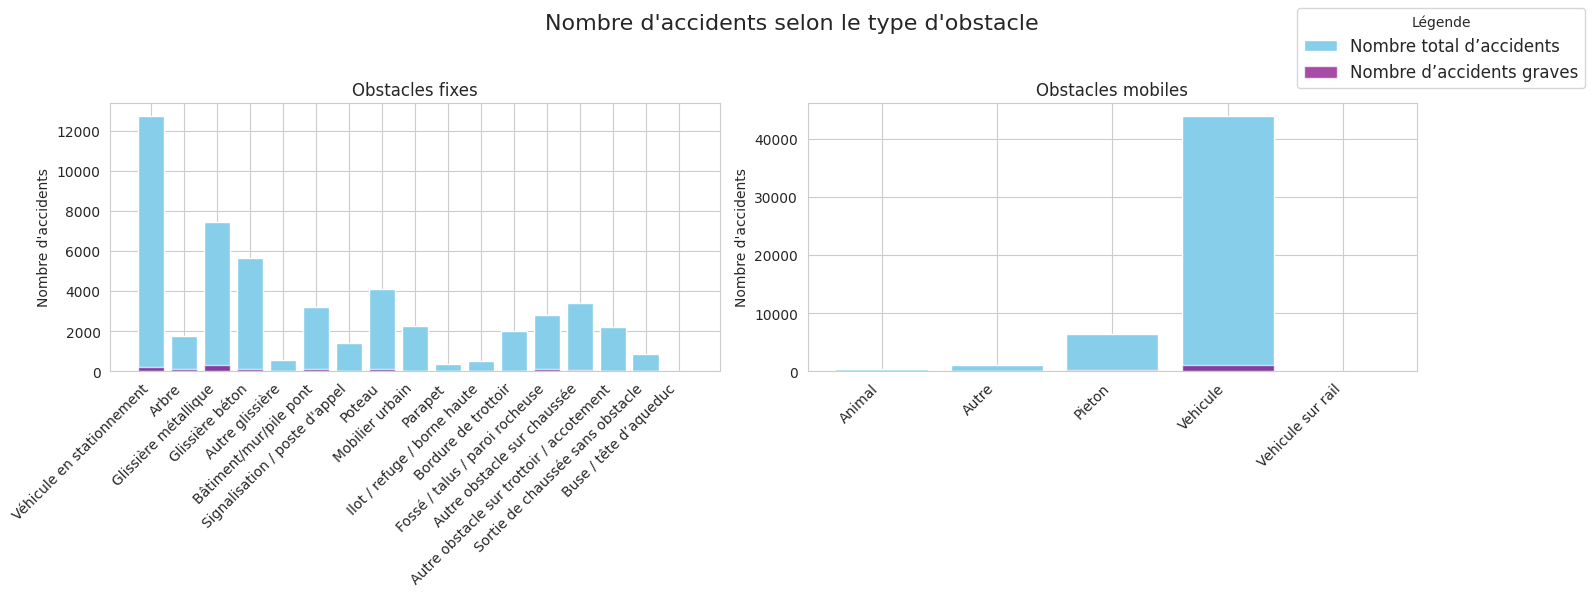

In [46]:
# --- Charger toutes les années ---
annees = [2014, 2015, 2016, 2017, 2018, 2020]
dfs = []

# Pour simplifier, obstacle fixe noms
obs_fix_map = {
    1: "Véhicule en stationnement",
    2: "Arbre",
    3: "Glissière métallique",
    4: "Glissière béton",
    5: "Autre glissière",
    6: "Bâtiment/mur/pile pont",
    7: "Signalisation / poste d'appel",
    8: "Poteau",
    9: "Mobilier urbain",
    10: "Parapet",
    11: "Ilot / refuge / borne haute",
    12: "Bordure de trottoir",
    13: "Fossé / talus / paroi rocheuse",
    14: "Autre obstacle sur chaussée",
    15: "Autre obstacle sur trottoir / accotement",
    16: "Sortie de chaussée sans obstacle",
    17: "Buse / tête d’aqueduc"
}

for annee in annees:
    df_veh = pd.read_csv(f'vehicules_{annee}.csv', encoding='latin1', sep=';', on_bad_lines='skip')
    df_usagers = pd.read_csv(f'usagers_{annee}.csv', encoding='latin1', sep=';', on_bad_lines='skip')

    df_veh['Num_Acc'] = df_veh['Num_Acc'].astype(str)
    df_usagers['Num_Acc'] = df_usagers['Num_Acc'].astype(str)

    df_merged = pd.merge(df_veh[['Num_Acc', 'obs', 'obsm']],
                         df_usagers[['Num_Acc', 'grav']],
                         on='Num_Acc', how='inner')

    df_filtered = df_merged[~df_merged['obs'].isin([-1,0])]
    df_filtered = df_filtered[~df_filtered['obsm'].isin([-1,0])]

    obsm_map = {
        1: 'Pieton',
        2: 'Vehicule',
        4: 'Vehicule sur rail',
        5: 'Animal', 6: 'Animal', 9: 'Autre'
    }
    df_filtered['obsm_group'] = df_filtered['obsm'].map(obsm_map)

    dfs.append(df_filtered)

df_all = pd.concat(dfs)

# --- Fixe ---
obs_fix_counts = df_all.groupby('obs')['Num_Acc'].count().reset_index()
obs_fix_counts.rename(columns={'Num_Acc':'nb_accidents'}, inplace=True)
obs_fix_grave = df_all[df_all['grav']==2].groupby('obs')['Num_Acc'].count().reset_index()
obs_fix_grave.rename(columns={'Num_Acc':'nb_graves'}, inplace=True)
obs_fix = obs_fix_counts.merge(obs_fix_grave, on='obs', how='left')
obs_fix['nb_graves'] = obs_fix['nb_graves'].fillna(0)
obs_fix['prop_graves'] = obs_fix['nb_graves']/obs_fix['nb_accidents']
obs_fix['label'] = obs_fix['obs'].map(obs_fix_map)

# --- Mobile ---
obs_mob_counts = df_all.groupby('obsm_group')['Num_Acc'].count().reset_index()
obs_mob_counts.rename(columns={'Num_Acc':'nb_accidents'}, inplace=True)
obs_mob_grave = df_all[df_all['grav']==2].groupby('obsm_group')['Num_Acc'].count().reset_index()
obs_mob_grave.rename(columns={'Num_Acc':'nb_graves'}, inplace=True)
obs_mob = obs_mob_counts.merge(obs_mob_grave, on='obsm_group', how='left')
obs_mob['nb_graves'] = obs_mob['nb_graves'].fillna(0)
obs_mob['prop_graves'] = obs_mob['nb_graves']/obs_mob['nb_accidents']

# --- Graphiques côte à côte ---
fig, axes = plt.subplots(1,2, figsize=(16,6))

# Fixe
axes[0].bar(obs_fix['label'], obs_fix['nb_accidents'], color='skyblue', label="Nombre total")
axes[0].bar(obs_fix['label'], obs_fix['nb_accidents']*obs_fix['prop_graves'],
            color='purple', alpha=0.7, label="Accidents graves")
axes[0].set_title("Obstacles fixes")
axes[0].set_ylabel("Nombre d'accidents")
axes[0].set_xticklabels(obs_fix['label'], rotation=45, ha='right')

# Mobile
axes[1].bar(obs_mob['obsm_group'], obs_mob['nb_accidents'], color='skyblue', label="Nombre total")
axes[1].bar(obs_mob['obsm_group'], obs_mob['nb_accidents']*obs_mob['prop_graves'],
            color='purple', alpha=0.7, label="Accidents graves")
axes[1].set_title("Obstacles mobiles")
axes[1].set_ylabel("Nombre d'accidents")
axes[1].set_xticklabels(obs_mob['obsm_group'], rotation=45, ha='right')

# --- Légende encadrée globale ---
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='skyblue', label='Nombre total d’accidents'),
    Patch(facecolor='purple', label='Nombre d’accidents graves', alpha=0.7)
]

# Pour fixer la position sur la droite
fig.legend(handles=legend_elements, loc='upper right', frameon=True, fontsize=12, title="Légende")

plt.suptitle("Nombre d'accidents selon le type d'obstacle", fontsize=16)
plt.tight_layout(rect=[0,0,0.9,0.95])  # pour laisser place à la légende
plt.show()

Après sélection des obstacles les plus représentatifs :

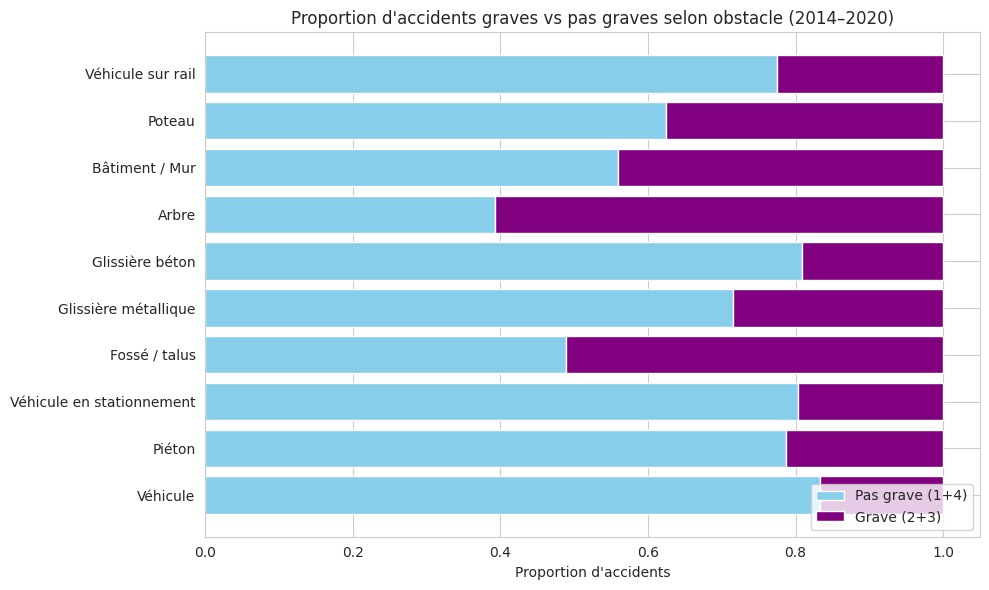

In [47]:
# --- Années à analyser ---
annees = [2014, 2015, 2016, 2017, 2018, 2020]

dfs = []

for annee in annees:
    df_veh = pd.read_csv(f'vehicules_{annee}.csv', encoding='latin1', sep=';', on_bad_lines='skip')
    df_usagers = pd.read_csv(f'usagers_{annee}.csv', encoding='latin1', sep=';', on_bad_lines='skip')

    df_veh['Num_Acc'] = df_veh['Num_Acc'].astype(str)
    df_usagers['Num_Acc'] = df_usagers['Num_Acc'].astype(str)

    df_merge = pd.merge(df_veh, df_usagers[['Num_Acc','grav']], on='Num_Acc', how='left')
    dfs.append(df_merge)

df_all = pd.concat(dfs, ignore_index=True)

# --- Obstacles d'intérêt ---
obstacles_fixes = {
    1: "Véhicule en stationnement",
    2: "Arbre",
    3: "Glissière métallique",
    4: "Glissière béton",
    6: "Bâtiment / Mur",
    8: "Poteau",
    13: "Fossé / talus"
}

obstacles_mobiles = {
    1: "Piéton",
    2: "Véhicule",
    4: "Véhicule sur rail",
}

df_all = df_all[df_all['obs'].isin(obstacles_fixes.keys()) | df_all['obsm'].isin(obstacles_mobiles.keys())]

df_all['obs_nom'] = df_all['obs'].map(obstacles_fixes)
df_all['obsm_nom'] = df_all['obsm'].map(obstacles_mobiles)

df_all['obstacle'] = df_all['obs_nom'].combine_first(df_all['obsm_nom'])
df_all = df_all[~df_all['obstacle'].isna()]

# --- Regrouper gravité ---
df_all['grav_cat'] = df_all['grav'].replace({1:'Pas grave', 4:'Pas grave', 2:'Grave', 3:'Grave'})

# --- Calcul proportion pour chaque obstacle ---
prop_df = df_all.groupby(['obstacle','grav_cat'])['Num_Acc'].count().reset_index()
prop_df = prop_df.pivot(index='obstacle', columns='grav_cat', values='Num_Acc').fillna(0)
prop_df['total'] = prop_df.sum(axis=1)
prop_df['prop_grave'] = prop_df['Grave'] / prop_df['total']
prop_df['prop_pas_grave'] = prop_df['Pas grave'] / prop_df['total']

# Trier par nombre total pour l'affichage
prop_df = prop_df.sort_values('total')

# --- Tracé empilé ---
fig, ax = plt.subplots(figsize=(10,6))
y_pos = range(len(prop_df))

ax.barh(y_pos, prop_df['prop_pas_grave'], color='skyblue', label='Pas grave (1+4)')
ax.barh(y_pos, prop_df['prop_grave'], left=prop_df['prop_pas_grave'], color='purple', label='Grave (2+3)')

ax.set_yticks(y_pos)
ax.set_yticklabels(prop_df.index)
ax.invert_yaxis()
ax.set_xlabel("Proportion d'accidents")
ax.set_title("Proportion d'accidents graves vs pas graves selon obstacle (2014–2020)")

# Légende encadrée
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Observations

L’analyse met en évidence plusieurs tendances intéressantes :

- L’arbre est l’obstacle le plus propice aux accidents graves, avec une proportion d’accidents graves supérieure à celle des accidents non graves.

- Le fossé / talus arrive en deuxième position, avec une répartition proche de 50 % d’accidents graves et 50 % d’accidents non graves.

- Les bâtiments / murs et les poteaux présentent également une proportion relativement élevée d’accidents graves, ce qui confirme que les collisions avec des obstacles fixes rigides sont particulièrement dangereuses.

- En comparaison, les obstacles mobiles (piétons et véhicules) présentent une proportion d’accidents graves plus faible que la majorité des obstacles fixes :

  - Les accidents impliquant des piétons comportent environ 20 % d’accidents graves.

  - Les accidents entre véhicules présentent une proportion légèrement inférieure.

De manière générale, les résultats montrent que les obstacles fixes sont associés à une proportion plus élevée d’accidents graves que les obstacles mobiles. Cela peut s’expliquer par la rigidité de ces structures et l’absence d’absorption d’énergie lors de l’impact.

## 4.2. Proportion de victimes graves selon la catégorie de véhicule

Dans cette partie, nous nous intéressons à la table vehicules afin d’analyser l’influence du type de véhicule sur la gravité des accidents.

Pour rendre l’analyse plus lisible, nous avons regroupé les nombreuses catégories initiales en 7 catégories principales :

- Voiture / VU léger : voitures particulières et véhicules utilitaires légers

- Deux-roues motorisés : scooters et motos de toutes cylindrées, tricycles motorisés

- Vélo / VAE : bicyclettes et vélos à assistance électrique

- Poids lourds : camions et tracteurs routiers

- Transport en commun : bus et autocars

- Autres : toutes les catégories restantes non classées ci-dessus

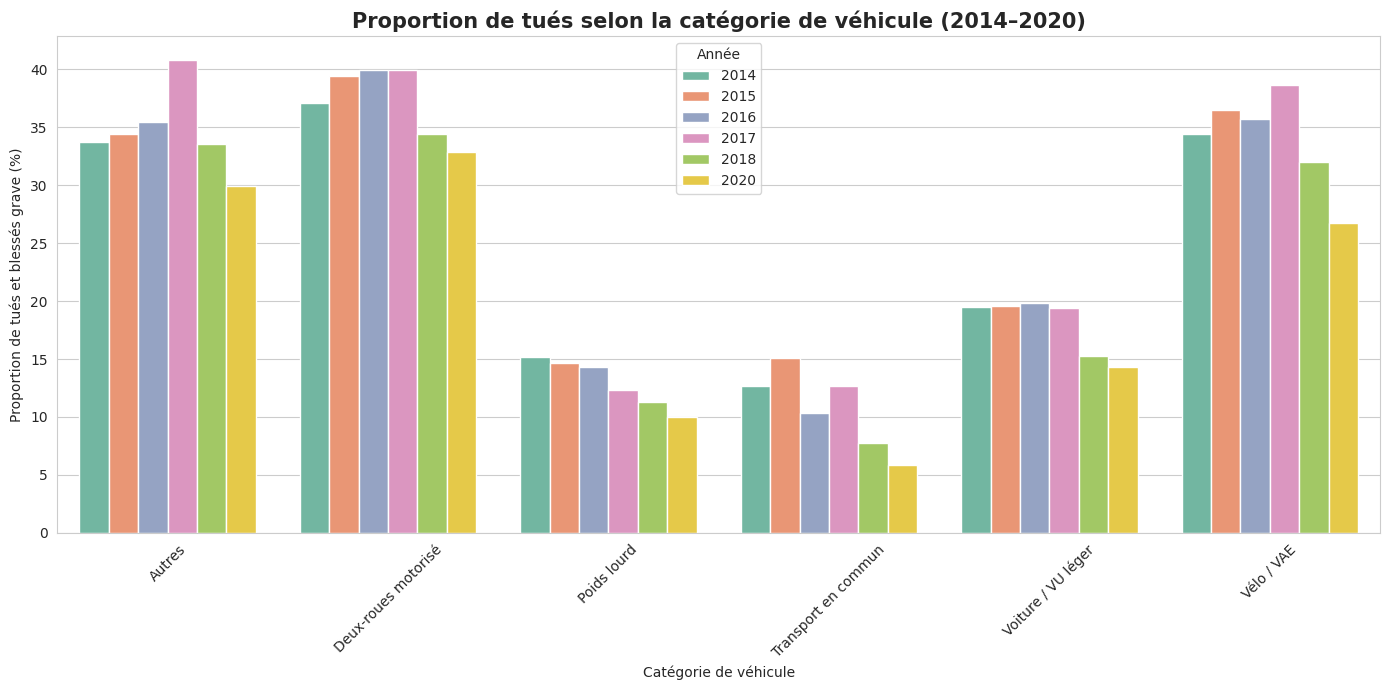

In [48]:
annees = [2014, 2015, 2016, 2017, 2018, 2020]

dfs_veh = []
dfs_usagers = []

# -------------------------
# 1. Chargement multi-années
# -------------------------

for annee in annees:

    veh = pd.read_csv(f"vehicules_{annee}.csv", sep=";", encoding="latin1")
    usa = pd.read_csv(f"usagers_{annee}.csv", sep=";", encoding="latin1")

    veh.columns = veh.columns.str.strip()
    usa.columns = usa.columns.str.strip()

    veh["annee"] = annee
    usa["annee"] = annee

    dfs_veh.append(veh)
    dfs_usagers.append(usa)

vehicules = pd.concat(dfs_veh, ignore_index=True)
usagers = pd.concat(dfs_usagers, ignore_index=True)

# -------------------------
# 2. Harmoniser types pour merge
# -------------------------

vehicules["Num_Acc"] = vehicules["Num_Acc"].astype(str)
vehicules["num_veh"] = vehicules["num_veh"].astype(str)

usagers["Num_Acc"] = usagers["Num_Acc"].astype(str)
usagers["num_veh"] = usagers["num_veh"].astype(str)

# -------------------------
# 3. Regrouper catégories véhicule
# -------------------------

def regrouper_catv(x):
    if x in [7, 10]:
        return "Voiture / VU léger"
    elif x in [30,31,32,33,34,41,42,43]:
        return "Deux-roues motorisé"
    elif x in [1, 80]:
        return "Vélo / VAE"
    elif x in [13,14,15,16,17]:
        return "Poids lourd"
    elif x in [37,38]:
        return "Transport en commun"
    else:
        return "Autres"

vehicules["catv_regroupe"] = vehicules["catv"].apply(regrouper_catv)

# -------------------------
# 4. Fusion
# -------------------------

df_merge = vehicules.merge(
    usagers[["Num_Acc", "num_veh", "grav", "annee"]],
    on=["Num_Acc", "num_veh", "annee"],
    how="inner"
)

# -------------------------
# 5. Variable tué
# -------------------------

df_merge["grave"] = df_merge["grav"].isin([2, 3]).astype(int)

# -------------------------
# 6. Calcul proportions par année
# -------------------------

proportions = (
    df_merge
    .groupby(["annee", "catv_regroupe"])["grave"]
    .mean()
    .reset_index()
)

proportions["grave"] *= 100

sns.set_style("whitegrid")

plt.figure(figsize=(14,7))

sns.barplot(
    data=proportions,
    x="catv_regroupe",
    y="grave",
    hue="annee",
    palette="Set2"

)

plt.title(
    "Proportion de tués selon la catégorie de véhicule (2014–2020)",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Catégorie de véhicule")
plt.ylabel("Proportion de tués et blessés grave (%)")
plt.xticks(rotation=45)
plt.legend(title="Année")

plt.tight_layout()
plt.show()

### Observations

- Les Deux-roues motorisés présentent systématiquement la proportion la plus élevée de victimes graves, ce qui souligne leur vulnérabilité.

- Les Vélo / VAE suivent, avec également un risque important mais légèrement inférieur aux deux-roues motorisés.

- La catégorie Autres affiche également une proportion relativement élevée, ce qui suggère que certains véhicules moins courants ou mal codés peuvent être associés à des accidents graves.

- Les Voitures / VU léger se situent dans la moyenne : proportion de gravité modérée mais supérieure aux poids lourds et transports en commun.

- Les catégories Poids lourds et Transport en commun montrent les proportions les plus faibles de victimes graves, ce qui peut refléter une meilleure protection des usagers ou la nature des accidents impliquant ces véhicules.

## 4.3. Proportion de victimes graves selon la manœuvre avant l’accident

Dans cette partie, nous nous intéressons à la table vehicules afin d’analyser l’influence de la manœuvre principale avant l’accident sur la gravité des accidents.
Pour rendre l’analyse plus lisible, nous avons regroupé les nombreuses catégories initiales en 7 catégories principales :

- **Sans changement / file normale** : l’usager suit sa trajectoire

- **Changement de direction** : changement de file, déport ou virage

- **Marche arrière / demi-tour** : recul ou demi-tour sur la chaussée

- **Contresens / franchissement** : sens inverse, franchissement du terre-plein ou insertion

- **Traversée / stationnement / arrêt** : traversée de chaussée, manœuvres de stationnement ou arrêt

- **Ouverture de porte** : ouverture de porte d’un véhicule

- **Autres / inconnue** : manœuvres non renseignées ou autres

L’objectif est de calculer, pour chaque année, la proportion de victimes graves (tués et blessés hospitalisés) parmi les usagers impliqués pour chaque catégorie de manœuvre.

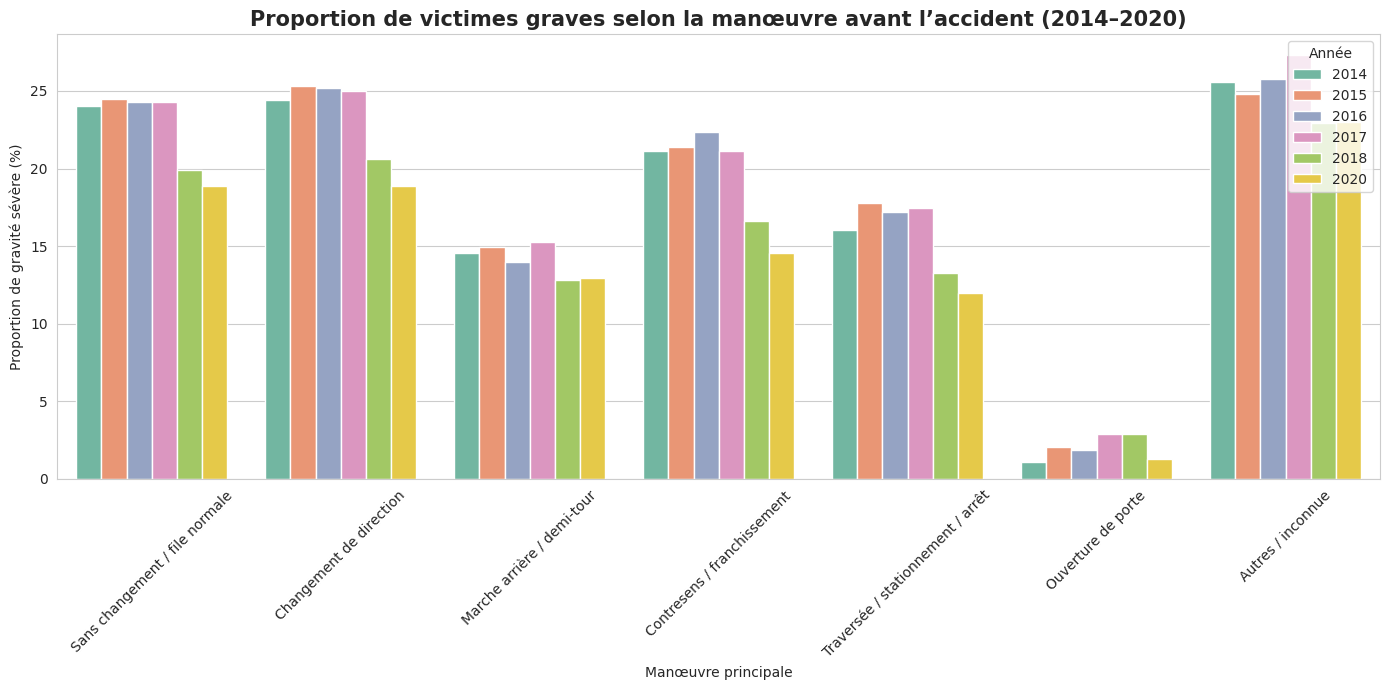

In [49]:
def regrouper_manv(x):
    if x in [1,2,3]:
        return "Sans changement / file normale"
    elif x in [11,12,13,14,15,16,17,18]:
        return "Changement de direction"
    elif x in [4,10]:
        return "Marche arrière / demi-tour"
    elif x in [5,6,7,8,9]:
        return "Contresens / franchissement"
    elif x in [19,20,23,24,25]:
        return "Traversée / stationnement / arrêt"
    elif x == 22:
        return "Ouverture de porte"
    elif x in [-1,0,26]:
        return "Autres / inconnue"
    else:
        return "Autres / inconnue"

df_merge["manv_regroupe"] = df_merge["manv"].apply(regrouper_manv)


proportions_manv = (
    df_merge
    .groupby(["annee", "manv_regroupe"])["grave"]
    .mean()
    .reset_index()
)

proportions_manv["grave"] *= 100

sns.set_style("whitegrid")
plt.figure(figsize=(14,7))

ordre_manv = [
    "Sans changement / file normale",
    "Changement de direction",
    "Marche arrière / demi-tour",
    "Contresens / franchissement",
    "Traversée / stationnement / arrêt",
    "Ouverture de porte",
    "Autres / inconnue"
]

sns.barplot(
    data=proportions_manv,
    x="manv_regroupe",
    y="grave",
    hue="annee",
    palette="Set2",
    order=ordre_manv
)

plt.title(
    "Proportion de victimes graves selon la manœuvre avant l’accident (2014–2020)",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Manœuvre principale")
plt.ylabel("Proportion de gravité sévère (%)")
plt.xticks(rotation=45)
plt.legend(title="Année")
plt.tight_layout()
plt.show()


### Observations

- La catégorie **Autres / inconnue** présente systématiquement la proportion la plus élevée de victimes graves, ce qui reflète des accidents complexes ou mal codés.

- La manœuvre **Ouverture de porte** montre une proportion très faible de victimes graves.

- Les catégories à risque modéré sont **Marche arrière / demi-tour** (probablement liée à une plus faible vitesse) et **Traversée / stationnement / arrêt**.

- Les catégories présentant un risque assez élevé de gravité sont **Sans changement / file normale**, **Changement de direction**, et **Contresens / franchissement**, ce qui indique que la plupart des accidents graves surviennent lorsque l’usager est en mouvement normal ou effectue une manœuvre complexe à risque.

## Synthèse de la partie "Véhicules"

Dans cette partie, nous analysons la table vehicules afin de comprendre comment le type de véhicule, les obstacles rencontrés et les manœuvres avant accident influencent la gravité des accidents. Cette analyse complète celle des caractéristiques et prépare la suite de notre étude visant à prédire la gravité des accidents.

#### Observations principales :

- **Obstacles rencontrés**

  - Les obstacles fixes (arbres, fossés/talus, bâtiments/murs, poteaux) sont systématiquement associés à une proportion plus élevée d’accidents graves que les obstacles mobiles.

  - L’arbre apparaît comme l’obstacle le plus dangereux, suivi du fossé/talus.

  - Les obstacles mobiles (piétons, véhicules) présentent une proportion d’accidents graves plus faible, généralement autour de 20 %.

    Ces résultats confirment que la rigidité des obstacles fixes augmente la gravité des accidents.

- **Catégorie de véhicule**

  - Les Deux-roues motorisés présentent la proportion la plus élevée de victimes graves, soulignant leur vulnérabilité.

  - Les Vélo / VAE suivent, avec un risque légèrement inférieur mais toujours élevé.

  - La catégorie Autres montre également une proportion élevée, probablement liée à des véhicules rares ou mal codés.

  - Les Voitures / VU léger se situent dans la moyenne.

  - Les Poids lourds et Transports en commun présentent les proportions les plus faibles de victimes graves, reflétant une meilleure protection ou des accidents moins violents pour les occupants.

- **Manœuvres avant accident**

  - Les catégories Sans changement / file normale, Changement de direction, et Contresens / franchissement sont associées à un risque assez élevé de gravité.

  - Les manœuvres Marche arrière / demi-tour et Traversée / stationnement / arrêt présentent un risque modéré, probablement lié à une vitesse plus faible.

  - La catégorie Ouverture de porte est très peu risquée.

  - La catégorie Autres / inconnue reste élevée, indiquant des situations complexes ou mal codées.

---

#### Conclusion et intérêt pour l’analyse de la gravité

Les variables les plus informative pour la gravité sont :

- **Type de véhicule** (Deux-roues, vélo/VAE, Autres)

- **Obstacle rencontré** (arbres, fossés, murs, poteaux)

- **Manœuvre avant accident** (sans changement, changement de direction, contresens)

Les variables moins informatives mais utiles pour le volume total d’accidents incluent : Poids lourds, transports en commun et certaines manœuvres rares.

# 5. Analyse des usagers impliqués dans les accidents

## 5.1. Analyse de la gravité en fonction de la place de l'usager

Nous nous intéressons à la gravité des accidents en fonction de la place occupée par l’usager dans le véhicule, afin de déterminer si certaines positions sont associées à un risque plus élevé de blessures graves ou mortelles.


<Figure size 1000x600 with 0 Axes>

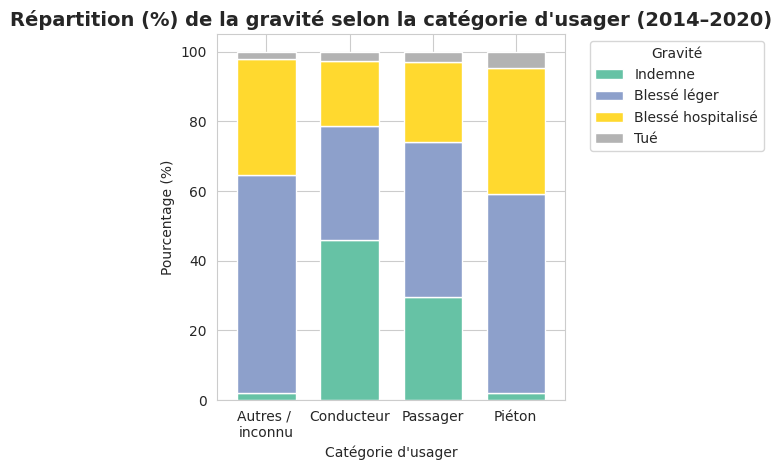

In [50]:
# -------------------------
# 1. Chargement multi-années
# -------------------------
annees = [2014, 2015, 2016, 2017, 2018, 2020]
dfs_usagers = []

for annee in annees:
    usa = pd.read_csv(f"usagers_{annee}.csv", sep=";", encoding="latin1")
    usa.columns = usa.columns.str.strip()
    usa["annee"] = annee
    dfs_usagers.append(usa)

usagers = pd.concat(dfs_usagers, ignore_index=True)

# Harmonisation
usagers["Num_Acc"] = usagers["Num_Acc"].astype(str)

# -------------------------
# 2. Regrouper catégorie d'usager
# -------------------------
def regrouper_catu(x):
    if x == 1:
        return "Conducteur"
    elif x == 2:
        return "Passager"
    elif x == 3:
        return "Piéton"
    else:
        return "Autres / \ninconnu"

usagers["catu_regroupe"] = usagers["catu"].apply(regrouper_catu)

# -------------------------
# 3. Regrouper gravité
# -------------------------
def regrouper_grav(x):
    if x == 1:
        return "Indemne"
    elif x == 2:
        return "Tué"
    elif x == 3:
        return "Blessé hospitalisé"
    elif x == 4:
        return "Blessé léger"
    else:
        return "Inconnu"

usagers["grav_regroupe"] = usagers["grav"].apply(regrouper_grav)

# -------------------------
# 4. Répartition en pourcentage
# -------------------------
repartition = (
    usagers.groupby(["catu_regroupe", "grav_regroupe"], observed=True)["Num_Acc"]
    .nunique()
    .reset_index(name="nombre_accidents")
)

# Pourcentage par catégorie
repartition["pourcentage"] = repartition["nombre_accidents"] / repartition.groupby("catu_regroupe")["nombre_accidents"].transform("sum") * 100

# -------------------------
# 5. Graphique empilé
# -------------------------
sns.set_style("whitegrid")
plt.figure(figsize=(10,6))

# On crée un pivot pour l'empilement
pivot = repartition.pivot(index="catu_regroupe", columns="grav_regroupe", values="pourcentage")
pivot = pivot[["Indemne", "Blessé léger", "Blessé hospitalisé", "Tué"]]  # ordre désiré

pivot.plot(kind="bar", stacked=True, colormap="Set2", width=0.7)

plt.title("Répartition (%) de la gravité selon la catégorie d'usager (2014–2020)", fontsize=14, weight="bold")
plt.xlabel("Catégorie d'usager")
plt.ylabel("Pourcentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Gravité", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Observations

- Les piétons sont les usagers les plus vulnérables lors d’un accident, étant les plus susceptibles d’être blessés ou tués, ce qui s’explique par l’absence de protection physique.

- Les passagers présentent surtout des blessures légères, et sont relativement peu concernés par les accidents graves ou mortels.

- Les conducteurs, quant à eux, sont majoritairement indemnes.


## 5.2. Répartition des usagers et de la gravité selon l’âge et la place de l'usager

Ces graphiques permettent de visualiser l’impact de l’âge sur l’implication des usagers dans les accidents et sur la gravité des blessures. L’objectif est de comprendre quelles tranches d’âge sont les plus exposées et comment la gravité se répartit selon l’âge, avant d’analyser plus finement d’autres facteurs comme la place dans le véhicule.

/tmp/ipykernel_767/2578986716.py:79: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  repartition_grav["nombre"] / repartition_grav.groupby("age_tranche")["nombre"].transform("sum") * 100


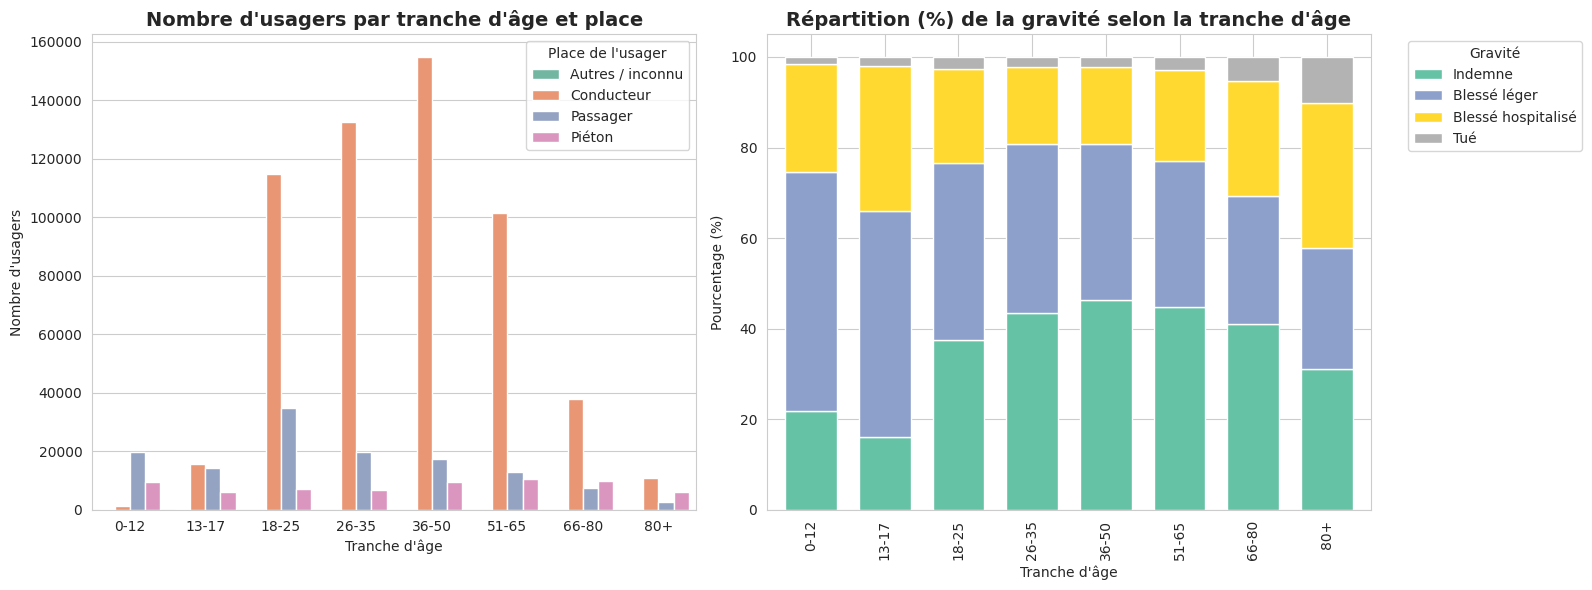

In [51]:
# -------------------------
# 1. Chargement multi-années
# -------------------------
annees = [2014, 2015, 2016, 2017, 2018, 2020]
dfs_usagers = []

for annee in annees:
    usa = pd.read_csv(f"usagers_{annee}.csv", sep=";", encoding="latin1")
    usa.columns = usa.columns.str.strip()
    usa["annee"] = annee
    dfs_usagers.append(usa)

usagers = pd.concat(dfs_usagers, ignore_index=True)

# Harmonisation
usagers["Num_Acc"] = usagers["Num_Acc"].astype(str)

# -------------------------
# 2. Tranche d'âge
# -------------------------
# Calcul âge en fonction de l'année de l'accident et de l'année de naissance
usagers["age"] = usagers["annee"] - usagers["an_nais"]

# Définir les tranches d'âge
bins = [0, 12, 17, 25, 35, 50, 65, 80, 120]
labels = ["0-12", "13-17", "18-25", "26-35", "36-50", "51-65", "66-80", "80+"]
usagers["age_tranche"] = pd.cut(usagers["age"], bins=bins, labels=labels, right=True)

# -------------------------
# 3. Place de l'usager
# -------------------------
def regrouper_catu(x):
    if x == 1:
        return "Conducteur"
    elif x == 2:
        return "Passager"
    elif x == 3:
        return "Piéton"
    else:
        return "Autres / inconnu"

usagers["place_lib"] = usagers["catu"].apply(regrouper_catu)

# -------------------------
# 4. Gravité
# -------------------------
def regrouper_grav(x):
    if x == 1:
        return "Indemne"
    elif x == 2:
        return "Tué"
    elif x == 3:
        return "Blessé hospitalisé"
    elif x == 4:
        return "Blessé léger"
    else:
        return "Inconnu"

usagers["grav_lib"] = usagers["grav"].apply(regrouper_grav)

# -------------------------
# 5. Préparer les données
# -------------------------

# a) Nombre d'usagers par tranche d'âge et place
effectifs = (
    usagers.groupby(["age_tranche", "place_lib"], observed=True)
    .size()
    .reset_index(name="nombre")
)

# b) Répartition de la gravité par tranche d'âge
repartition_grav = (
    usagers.groupby(["age_tranche", "grav_lib"], observed=True)["Num_Acc"]
    .nunique()
    .reset_index(name="nombre")
)
repartition_grav["pourcentage"] = (
    repartition_grav["nombre"] / repartition_grav.groupby("age_tranche")["nombre"].transform("sum") * 100
)

# -------------------------
# 6. Graphiques côte à côte
# -------------------------
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# ----- Graphique 1 : effectifs par âge et place -----
sns.barplot(
    data=effectifs,
    x="age_tranche",
    y="nombre",
    hue="place_lib",
    palette="Set2",
    ax=axes[0]
)
axes[0].set_title("Nombre d'usagers par tranche d'âge et place", fontsize=14, weight="bold")
axes[0].set_xlabel("Tranche d'âge")
axes[0].set_ylabel("Nombre d'usagers")
axes[0].legend(title="Place de l'usager")

# ----- Graphique 2 : répartition de la gravité par âge -----
pivot = repartition_grav.pivot(index="age_tranche", columns="grav_lib", values="pourcentage").fillna(0)
pivot = pivot[["Indemne", "Blessé léger", "Blessé hospitalisé", "Tué"]]

pivot.plot(kind="bar", stacked=True, colormap="Set2", width=0.7, ax=axes[1])
axes[1].set_title("Répartition (%) de la gravité selon la tranche d'âge", fontsize=14, weight="bold")
axes[1].set_xlabel("Tranche d'âge")
axes[1].set_ylabel("Pourcentage (%)")
axes[1].legend(title="Gravité", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

### Observations

**Effectifs par tranche d’âge et place :**

- Les usagers les plus impliqués dans les accidents sont les 36–50 ans, suivis des 26–35 ans, puis des 18–25 ans, et enfin des 51–65 ans.

- La majorité des accidents impliquent des conducteurs, toutes tranches d’âge confondues.

- Les autres catégories (Passager, Piéton, Autre) restent minoritaires pour presque toutes les tranches, à l’exception des 0–12 ans, 13–17 ans et 80+ ans, où le conducteur est peu ou pas représenté.

---

**Répartition de la gravité par tranche d’âge :**

- On observe une distribution concentrée autour des 26–35 ans et 36–50 ans, avec la plus forte proportion d’indemnes et de blessés légers.

- Cette tendance peut s’expliquer de deux manières :

  - Les tranches d’âge intermédiaires sont moins vulnérables aux blessures graves.

  - Ce sont aussi principalement des conducteurs, qui, comme montré précédemment, sont globalement moins gravement blessés que les passagers ou piétons.

---

**Conclusion rapide :**
La gravité des blessures semble donc être liée à la fois à l’âge et à la place dans le véhicule, avec un effet combiné qui favorise les conducteurs adultes comme étant les moins touchés gravement.

## 5.3. Répartition du nombre d'accidents enregistrés et gravité selon du sexe


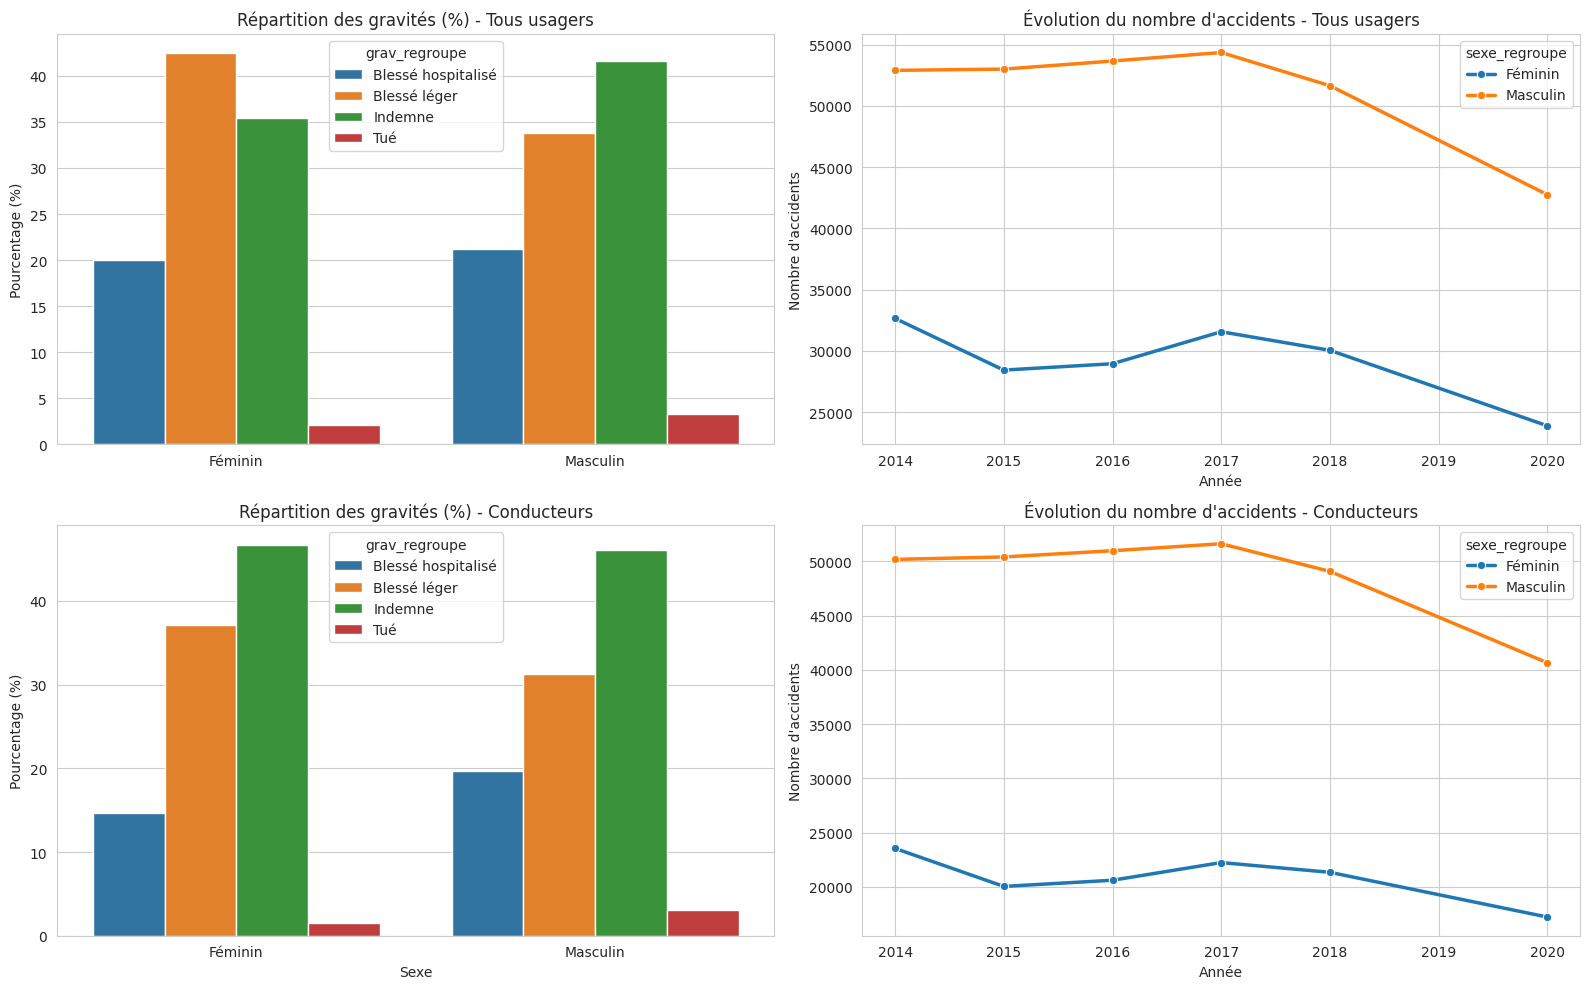

In [52]:
annees = [2014, 2015, 2016, 2017, 2018, 2020]
dfs_usagers = []

# -------------------------
# 1. Chargement multi-années
# -------------------------
for annee in annees:
    usa = pd.read_csv(f"usagers_{annee}.csv", sep=";", encoding="latin1")
    usa.columns = usa.columns.str.strip()
    usa["annee"] = annee
    dfs_usagers.append(usa)

usagers = pd.concat(dfs_usagers, ignore_index=True)
usagers["Num_Acc"] = usagers["Num_Acc"].astype(str)

# -------------------------
# 2. Regrouper sexe
# -------------------------
def regrouper_sexe(x):
    if x == 1:
        return "Masculin"
    elif x == 2:
        return "Féminin"
    else:
        return "Autres / inconnu"

usagers["sexe_regroupe"] = usagers["sexe"].apply(regrouper_sexe)

# -------------------------
# 3. Regrouper gravité
# -------------------------
def regrouper_grav(x):
    if x == 1:
        return "Indemne"
    elif x == 2:
        return "Tué"
    elif x == 3:
        return "Blessé hospitalisé"
    elif x == 4:
        return "Blessé léger"
    else:
        return "Inconnu"

usagers["grav_regroupe"] = usagers["grav"].apply(regrouper_grav)

# -------------------------
# 4. Répartition des gravités (%) par sexe
# -------------------------
accidents_grav = usagers[["Num_Acc", "sexe_regroupe", "grav_regroupe"]].drop_duplicates()

repartition_grav = (
    accidents_grav.groupby(["sexe_regroupe", "grav_regroupe"], observed=True)["Num_Acc"]
    .nunique()
    .reset_index(name="nombre")
)

repartition_grav["pourcentage"] = (
    repartition_grav["nombre"] / repartition_grav.groupby("sexe_regroupe")["nombre"].transform("sum") * 100
)

# -------------------------
# 5. Nombre d'accidents par sexe ET par année
# -------------------------
nb_accidents_annee = (
    usagers.groupby(["annee", "sexe_regroupe"])["Num_Acc"]
    .nunique()
    .reset_index(name="nombre_accidents")
)

# -------------------------
# 6. Conducteurs uniquement
# -------------------------
conducteurs = usagers[usagers["place"] == 1]

accidents_grav_cond = (
    conducteurs[["Num_Acc", "sexe_regroupe", "grav_regroupe"]].drop_duplicates()
)

repartition_grav_cond = (
    accidents_grav_cond.groupby(["sexe_regroupe", "grav_regroupe"], observed=True)["Num_Acc"]
    .nunique()
    .reset_index(name="nombre")
)

repartition_grav_cond["pourcentage"] = (
    repartition_grav_cond["nombre"] / repartition_grav_cond.groupby("sexe_regroupe")["nombre"].transform("sum") * 100
)

nb_accidents_annee_cond = (
    conducteurs.groupby(["annee", "sexe_regroupe"])["Num_Acc"]
    .nunique()
    .reset_index(name="nombre_accidents")
)

# -------------------------
# 7. Graphiques 2x2
# -------------------------
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16,10))

# ----- Ligne 1 : Tous usagers -----
sns.barplot(
    data=repartition_grav,
    x="sexe_regroupe",
    y="pourcentage",
    hue="grav_regroupe",
    ax=axes[0,0]
)
axes[0,0].set_title("Répartition des gravités (%) - Tous usagers")
axes[0,0].set_ylabel("Pourcentage (%)")
axes[0,0].set_xlabel("")

sns.lineplot(
    data=nb_accidents_annee,
    x="annee",
    y="nombre_accidents",
    hue="sexe_regroupe",
    marker="o",
    linewidth=2.5,
    ax=axes[0,1]
)
axes[0,1].set_title("Évolution du nombre d'accidents - Tous usagers")
axes[0,1].set_ylabel("Nombre d'accidents")
axes[0,1].set_xlabel("Année")

# ----- Ligne 2 : Conducteurs -----
sns.barplot(
    data=repartition_grav_cond,
    x="sexe_regroupe",
    y="pourcentage",
    hue="grav_regroupe",
    ax=axes[1,0]
)
axes[1,0].set_title("Répartition des gravités (%) - Conducteurs")
axes[1,0].set_ylabel("Pourcentage (%)")
axes[1,0].set_xlabel("Sexe")

sns.lineplot(
    data=nb_accidents_annee_cond,
    x="annee",
    y="nombre_accidents",
    hue="sexe_regroupe",
    marker="o",
    linewidth=2.5,
    ax=axes[1,1]
)
axes[1,1].set_title("Évolution du nombre d'accidents - Conducteurs")
axes[1,1].set_ylabel("Nombre d'accidents")
axes[1,1].set_xlabel("Année")

plt.tight_layout()
plt.show()

### Observations

- Nombre d’accidents : Les femmes sont globalement moins impliquées que les hommes, que l’on considère tous les usagers ou uniquement les conducteurs. Chez ces derniers, elles représentent environ la moitié du nombre d’accidents masculins.

- Tendance 2020 : On observe une baisse du nombre total d’accidents cette année, cohérente avec les effets du confinement évoqués précédemment (cf "*1.2. Les évolutions par année*").

- Gravité des accidents : Les femmes semblent légèrement plus vulnérables : elles ont une proportion plus élevée de blessées, tandis que les hommes enregistrent un peu plus de décès, aussi bien chez les conducteurs que tous usagers confondus.

Ces observations confirment que le sexe est un facteur intéressant à considérer pour l’analyse des accidents et de leur gravité, tout en restant à interpréter avec prudence compte tenu des effectifs relatifs.

## 5.4. Influence du port d'équipements de sécurité sur la gravité de l'accident

Dans cette section, nous analysons l’impact des équipements de sécurité portés par les usagers (ceinture, casque, gants, airbag, dispositif enfant, etc.) sur la gravité des accidents. Les combinaisons multiples ou non renseignées sont regroupées afin de simplifier l’interprétation des résultats.


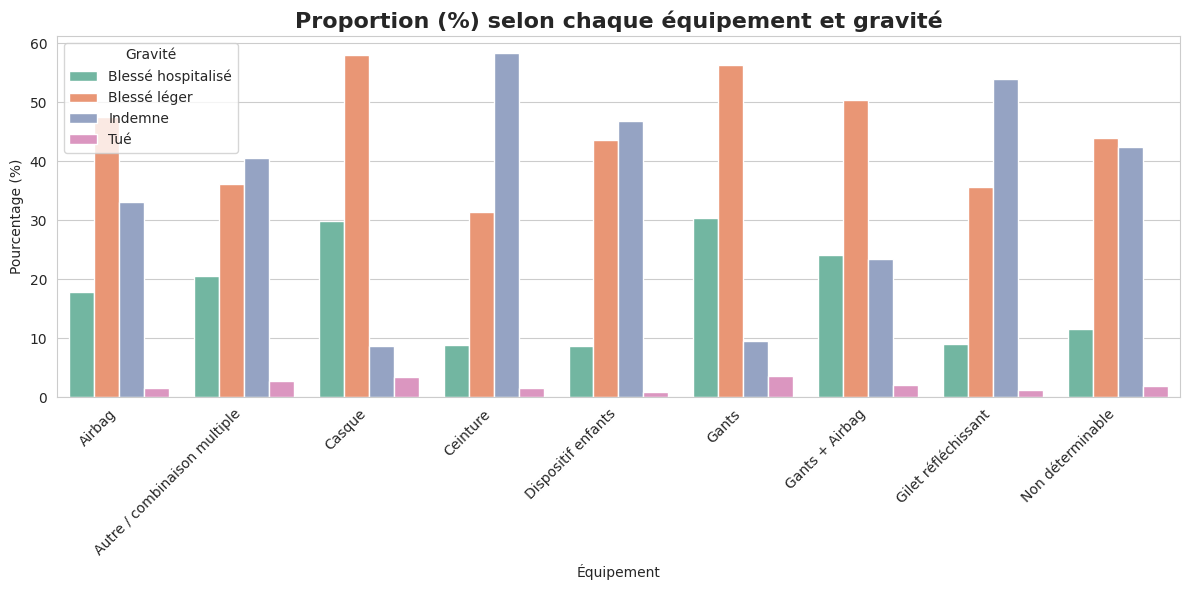

In [53]:
# -------------------------
# 1. Import multi-années
# -------------------------
annees = [2014, 2015, 2016, 2017, 2018, 2020]
dfs_usagers = []

for annee in annees:
    usa = pd.read_csv(f"usagers_{annee}.csv", sep=";", encoding="latin1")
    usa.columns = usa.columns.str.strip()
    usa["annee"] = annee
    dfs_usagers.append(usa)

df = pd.concat(dfs_usagers, ignore_index=True)

# -------------------------
# 2. Harmoniser gravité
# -------------------------
def regrouper_grav(x):
    if x == 1:
        return "Indemne"
    elif x == 2:
        return "Tué"
    elif x == 3:
        return "Blessé hospitalisé"
    elif x == 4:
        return "Blessé léger"
    else:
        return "Inconnu"

df["grav"] = df["grav"].apply(regrouper_grav)

# -------------------------
# 3. Créer la colonne secu_final
# -------------------------
type_labels = {
    1: "Ceinture",
    2: "Casque",
    3: "Dispositif enfants",
    4: "Gilet réfléchissant",
    5: "Airbag",
    6: "Gants",
    7: "Gants + Airbag",
    8: "Non déterminable",
    9: "Autre"
}

def process_secu(row):
    secu_list = []
    # Cas 2020 : colonnes secu1, secu2, secu3
    if "secu1" in row.index:
        for col in ["secu1","secu2","secu3"]:
            val = row[col]
            try:
                val_int = int(val)
                if val_int > 0:
                    secu_list.append(type_labels.get(val_int, "Autre"))
            except:
                continue
    # Cas 2014-2018 : colonne unique 'secu'
    elif "secu" in row.index:
        s = str(row["secu"])
        for c in s:
            if c.isdigit():
                c_int = int(c)
                if c_int > 0:
                    secu_list.append(type_labels.get(c_int, "Autre"))
    if not secu_list:
        secu_list = ["Aucun équipement"]
    return "; ".join(secu_list)

df["secu_final"] = df.apply(process_secu, axis=1)

# -------------------------
# 4. Regrouper pour le graphique
# -------------------------
equip_types = ["Ceinture", "Casque", "Dispositif enfants", "Gilet réfléchissant",
               "Airbag", "Gants", "Gants + Airbag", "Non déterminable"]

rows = []
for i, row in df.iterrows():
    if pd.isna(row["secu_final"]) or row["secu_final"] == "":
        equip_list = ["Aucun équipement"]
    else:
        equip_list = [equip for equip in equip_types if equip in row["secu_final"]]
        if not equip_list:
            equip_list = ["Autre / combinaison multiple"]
    for equip in equip_list:
        rows.append({"equip": equip, "grav": row["grav"]})

df_long = pd.DataFrame(rows)

# -------------------------
# 5. Calcul proportion par équipement et gravité
# -------------------------
counts = df_long.groupby(["equip", "grav"], observed=True).size().reset_index(name="nombre")
total = counts.groupby("equip")["nombre"].transform("sum")
counts["pourcentage"] = counts["nombre"] / total * 100

# -------------------------
# 6. Graphique barplot empilé
# -------------------------
plt.figure(figsize=(12,6))
sns.set_style("whitegrid")
sns.barplot(data=counts, x="equip", y="pourcentage", hue="grav", palette="Set2")

plt.title("Proportion (%) selon chaque équipement et gravité", fontsize=16, weight="bold")
plt.xlabel("Équipement")
plt.ylabel("Pourcentage (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Gravité")
plt.tight_layout()
plt.show()

### Observations

- La ceinture se distingue clairement : la majorité des usagers équipés restent indemnes, ce qui illustre son efficacité dans la protection des occupants.

- Pour les équipements associés aux véhicules motorisés (casque, gants, gants + airbag, airbag), on observe que le nombre de blessés légers est le plus élevé, suivi des blessés graves, puis des indemnes, et enfin des tués. Cela suggère que ces types de véhicules sont plus exposés à des blessures, même avec protection.

- Les catégories Autre / combinaison multiple, dispositif enfant, et non déterminable présentent des distributions où les blessés légers et les indemnes sont à peu près équivalents, avec une proportion plus faible de blessés graves et de tués.

- Globalement, les équipements de sécurité sont associés à des niveaux de gravité différents selon le type de véhicule et la situation, mais la ceinture reste l’équipement le plus protecteur.

## 5.5. Analyse de la gravité en fonction du type de trajet

Cette partie explore la relation entre le type de trajet effectué par l’usager et la gravité des accidents. L’idée est de se demander si des trajets très routiniers, connus par cœur, entraînent moins ou plus d’accidents graves comparés à des trajets de loisir ou occasionnels, où l’attention pourrait être moindre ou les imprévus plus fréquents.


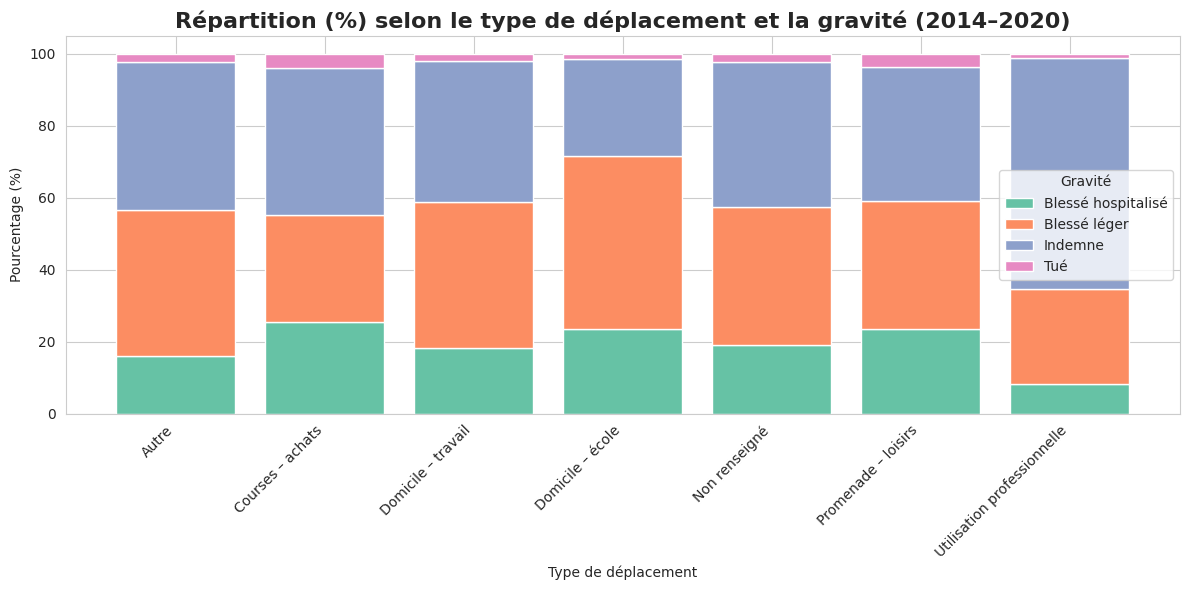

In [54]:
# -------------------------
# 1. Réimport multi-années
# -------------------------
annees = [2014, 2015, 2016, 2017, 2018, 2020]
dfs_usagers = []

for annee in annees:
    usa = pd.read_csv(f"usagers_{annee}.csv", sep=";", encoding="latin1")
    usa.columns = usa.columns.str.strip()
    usa["annee"] = annee
    dfs_usagers.append(usa)

df = pd.concat(dfs_usagers, ignore_index=True)

# -------------------------
# 2. Harmoniser gravité
# -------------------------
def regrouper_grav(x):
    if x == 1:
        return "Indemne"
    elif x == 2:
        return "Tué"
    elif x == 3:
        return "Blessé hospitalisé"
    elif x == 4:
        return "Blessé léger"
    else:
        return "Inconnu"

df["grav_lib"] = df["grav"].apply(regrouper_grav)

# -------------------------
# 3. Mapper trajet
# -------------------------
trajet_map = {
    -1: "Non renseigné",
     0: "Non renseigné",
     1: "Domicile – travail",
     2: "Domicile – école",
     3: "Courses – achats",
     4: "Utilisation professionnelle",
     5: "Promenade – loisirs",
     9: "Autre"
}

df["deplacement_lib"] = df["trajet"].map(trajet_map).fillna("Non renseigné")

# -------------------------
# 4. Créer un dataframe "long"
# -------------------------
rows = []
for i, row in df.iterrows():
    dep = row["deplacement_lib"]
    rows.append({"deplacement": dep, "grav": row["grav_lib"]})

df_long = pd.DataFrame(rows)

# -------------------------
# 5. Calcul proportion par type de déplacement et gravité
# -------------------------
counts = df_long.groupby(["deplacement", "grav"], observed=True).size().reset_index(name="nombre")
total = counts.groupby("deplacement")["nombre"].transform("sum")
counts["pourcentage"] = counts["nombre"] / total * 100

# -------------------------
# 6. Graphique barplot empilé
# -------------------------
plt.figure(figsize=(12,6))
sns.set_style("whitegrid")

pivot = counts.pivot(index="deplacement", columns="grav", values="pourcentage").fillna(0)

bottom = np.zeros(len(pivot))
colors = sns.color_palette("Set2", n_colors=len(pivot.columns))
for i, col in enumerate(pivot.columns):
    plt.bar(pivot.index, pivot[col], bottom=bottom, label=col, color=colors[i])
    bottom += pivot[col].values

plt.title("Répartition (%) selon le type de déplacement et la gravité (2014–2020)", fontsize=16, weight="bold")
plt.ylabel("Pourcentage (%)")
plt.xlabel("Type de déplacement")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Gravité")
plt.tight_layout()
plt.show()

### Observations

**Tendance générale :**

- Les catégories les plus représentées sont les indemnes et les blessés légers pour presque tous les types de trajet. Cela reflète le fait que la majorité des accidents impliquent des dommages légers ou n’entraînent pas de blessures graves.

- Les répartitions sont relativement similaires entre les différents types de trajets, ce qui montre que le risque global de blessure est assez homogène selon le motif du déplacement.

---

**Cas particuliers :**

- *Utilisation professionnelle* : on observe beaucoup plus d’indemnes par rapport aux autres catégories. Cela peut s’expliquer par le fait que les accidents liés au travail impliquent souvent des véhicules plus adaptés (camions, utilitaires) et des conducteurs expérimentés, réduisant la gravité des blessures.

- *Domicile – école* : cette catégorie présente le moins d’indemnes et le plus de blessés légers. Cela pourrait s’expliquer par la présence d’usagers plus vulnérables (enfants, adolescents) et par des conditions de circulation particulières autour des écoles, où les accidents sont plus fréquents mais rarement graves.

## Synthèse de la partie "Usagers"

Dans cette partie, nous avons analysé la table usagers afin de comprendre comment la place dans le véhicule, l’âge, le sexe, l’équipement de sécurité et le motif du déplacement influencent la gravité des accidents. Ces analyses préparent la suite de notre étude pour identifier les facteurs les plus pertinents pour prédire la gravité des accidents.

#### Observations principales :

- **Catégorie d’usager**

  - Les piétons sont les plus vulnérables, avec une probabilité élevée d’être blessés ou tués, ce qui s’explique par l’absence de protection physique.

  - Les passagers présentent surtout des blessures légères et sont relativement peu concernés par les accidents graves ou mortels.

  - Les conducteurs sont majoritairement indemnes, ce qui reflète à la fois leur position dans le véhicule et un niveau d’exposition différent par rapport aux autres catégories.

- **Âge et place dans le véhicule**

  - Les tranches d’âge les plus impliquées dans les accidents sont 36–50 ans, suivies des 26–35 ans, 18–25 ans, puis 51–65 ans.

  - La majorité des accidents implique des conducteurs, toutes tranches confondues, tandis que les autres catégories restent minoritaires sauf pour les enfants (0–12 ans), adolescents (13–17 ans) et personnes âgées (80+ ans).

  - La répartition de la gravité montre que les catégories 26–35 ans et 36–50 ans comptent le plus d’indemnes et de blessés légers. Cette tendance peut s’expliquer par une vulnérabilité moindre liée à l’âge et par le fait qu’ils sont majoritairement conducteurs, qui sont globalement moins gravement blessés.

- **Sexe**

  - Les femmes sont globalement moins impliquées que les hommes, que l’on considère tous usagers ou uniquement les conducteurs.

  - Chez les conducteurs, elles représentent environ la moitié du nombre d’accidents masculins.

  - On note une légère vulnérabilité : les femmes ont proportionnellement plus de blessées légères et hospitalisées, tandis que les hommes enregistrent légèrement plus de décès.

- **Équipement de sécurité**

  - La ceinture se distingue par son efficacité : les usagers équipés restent majoritairement indemnes.

  - Les autres équipements (casque, gants, airbag, gants + airbag) montrent davantage de blessés légers et hospitalisés, suggérant que les véhicules motorisés nécessitent une protection supplémentaire mais restent exposés.

  - Les catégories *Autre / combinaison multiple*, *dispositif enfant* et *non déterminable* présentent des distributions plus équilibrées entre indemnes et blessés légers.

- **Motif du déplacement**

  - La majorité des accidents concerne les indemnes et blessés légers, ce qui montre que le risque global reste modéré selon le motif du déplacement.

  - Pour les utilisations professionnelles, la proportion d’indemnes est plus élevée, probablement liée à des conducteurs expérimentés ou des véhicules adaptés.

  - Pour le *domicile – école*, on observe moins d’indemnes et plus de blessés légers, ce qui s’explique par la présence d’usagers plus vulnérables (enfants, adolescents) et des conditions de circulation spécifiques autour des établissements scolaires.

---

#### Conclusion et intérêt pour l’analyse de la gravité

Les variables les plus informatives pour la gravité sont :

- **Place dans le véhicule** (conducteur, passager, piéton)

- **Âge** (catégories intermédiaires 26–50 ans moins vulnérables)

- **Équipement de sécurité** (ceinture et autres protections)

Les variables comme le sexe et le motif du déplacement apportent des informations complémentaires pour comprendre la distribution des accidents et préparer la sélection des facteurs pertinents pour un futur modèle prédictif de la gravité.


# Synthèse générale de l’exploration des données

Ce notebook avait pour objectif d’explorer les données d’accidents de la route entre 2014 et 2020 (hors 2019), afin de comprendre la structure des bases et d’identifier les variables les plus pertinentes pour expliquer et prédire la gravité des accidents.

L’analyse a été organisée autour de quatre dimensions complémentaires :
**caractéristiques** générales de l’accident, **lieux**, **véhicules** et **usagers**.

Globalement, deux grands types de variables se dégagent :

- des variables qui expliquent surtout le volume total d’accidents (effet d’exposition),

- des variables qui semblent réellement associées à la gravité des accidents.

---

### 1. Variables principalement liées au volume d’accidents

Certaines catégories concentrent un grand nombre d’accidents simplement parce qu’elles sont plus fréquentes dans la réalité :

- Les voies communales et départementales, qui représentent la majorité du réseau routier.

- Les lignes droites et les routes sans aménagement particulier.

- Les surfaces normales, beaucoup plus fréquentes que les surfaces dégradées.

- Les départements densément peuplés (Paris, Rhône, Bouches-du-Rhône).

- Les plages horaires de forte circulation (7h–20h).

Dans ces cas, le nombre élevé d’accidents semble davantage lié à l’exposition qu’à un risque intrinsèque plus élevé.

### 2. Variables associées à une gravité plus importante

Plusieurs facteurs apparaissent comme potentiellement déterminants pour expliquer la gravité :

- Luminosité et éclairage : la nuit sans éclairage public est associée à davantage d’accidents graves.

- Type de collision : collisions frontales et accidents sans collision présentent une gravité plus élevée.

- Obstacles fixes (arbres, fossés, murs, poteaux), qui augmentent fortement la proportion d’accidents graves.

- Type de véhicule : deux-roues motorisés et vélos/VAE se distinguent par une vulnérabilité marquée.

- Catégorie d’usager : les piétons sont les plus exposés aux formes graves.

- Tracés en courbe, qui semblent proportionnellement plus associés aux blessures hospitalisées et aux décès.

Ces variables traduisent soit une vulnérabilité physique (piétons, deux-roues), soit une violence potentielle du choc (collision frontale, obstacle fixe), soit des conditions de visibilité ou de contrôle réduites (nuit, courbes).

### 3. Variables à effet plus modéré ou complémentaire

Certaines variables montrent des différences plus faibles ou nécessitent une interprétation prudente :

- L’état de la surface (normale vs mouillée) ne montre pas de variation nette de gravité.

- La localisation en agglomération / hors agglomération présente des proportions proches.

- Le sexe et le motif du déplacement apportent des nuances intéressantes mais moins déterminantes que la catégorie d’usager ou le type de véhicule.

- Certaines infrastructures (ponts, voies ferrées) semblent associées à une gravité plus élevée, mais les effectifs restent faibles, limitant la robustesse des conclusions.

---

#### **Conclusion générale et perspectives**

Cette exploration met en évidence que la gravité des accidents ne dépend pas uniquement du lieu ou du volume d’exposition, mais résulte d’une combinaison de facteurs liés :

- à la vulnérabilité des usagers,

- aux caractéristiques des véhicules,

- aux conditions de circulation et de visibilité,

- et à la nature de l’impact.

Les variables les plus prometteuses pour un futur modèle prédictif de la gravité semblent être :

- le **type de collision**,

- la **luminosité**,

- le **type de véhicule**,

- la **catégorie d’usager**,

- les **obstacles rencontrés**,

- et certains éléments du **tracé routier**.

Cette phase exploratoire a permis de mieux comprendre la structure des données, d’identifier les facteurs potentiellement explicatifs de la gravité, et de poser des bases solides pour une modélisation statistique ultérieure.